# TSB Method for Intermittent Demand with `numpyro_forecast`

This notebook ports the blog post [**TSB Method for Intermittent Time Series Forecasting in NumPyro**](https://juanitorduz.github.io/tsb_numpyro/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. It is the direct follow-up to the [Croston example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html), and rather than re-deriving intermittent demand from scratch, we focus on the one thing the **Teunter-Syntetos-Babai (TSB)** method changes and why that change matters.

The setup is the same. **Intermittent demand** series are dominated by zeros, with the occasional non-zero demand arriving at irregular times (spare parts, slow-moving SKUs). [Croston's method](https://juanitorduz.github.io/croston_numpyro/) splits the series $y_t$ into **demand sizes** $z_t$ (the non-zero values) and **demand intervals** $p_t$ (the gaps between demands), smooths each with simple exponential smoothing, and forecasts the ratio $\hat{z}_t / \hat{p}_t$: the expected demand per period. Its well-known weakness is that both components update **only at demand events**. Once demand stops, a Croston forecast never moves again: it stays frozen at the last level no matter how long the drought runs, so it cannot express that a slow item is going obsolete.

TSB fixes exactly this. It keeps the demand-size channel unchanged, but replaces the interval channel with a **demand probability** $p_t \in [0, 1]$ that is smoothed at **every period**, not just at demand events:

$$\hat{y}_{t+h} = \hat{z}_t \cdot \hat{p}_t,$$

the expected demand size times the probability that a demand occurs. Because the probability is updated on every zero as well as every demand, it **decays geometrically through a run of zeros** and jumps back up at the next demand, so the forecast responds to the *recency* of demand. That single structural change, one smoothing recursion that runs every period instead of only at events, is the whole story, and it is what this notebook makes concrete. As a side benefit, TSB smooths a probability directly instead of an inverse interval, so it sidesteps the inversion (Jensen) bias and the Syntetos-Boylan correction that the Croston notebook has to reckon with.

Two practical notes on the port, unchanged from the [Croston example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html):

- We reuse the *same* reusable `level_model` (the simple exponential smoothing level model from the blog's [exponential smoothing predecessor](https://juanitorduz.github.io/exponential_smoothing_numpyro/)) on the **raw calendar timeline**: one `jax.lax.scan` runs each level recursion, and demand events are marked with a boolean indicator. The only difference from Croston lives in *how that indicator is used*: Croston freezes the level (and masks the likelihood) outside demand events, while TSB's probability channel updates on every period. Everything plugs straight into `fit_mcmc`, `to_datatree`, and `backtest`.
- The observed series itself plays the role of the covariates, because the model needs the demand history to run its recursions, and `covariates` is the carrier that spans the full horizon at prediction time. The model only ever reads the first `t_obs` rows, so no future information leaks into a forecast.

## Prepare notebook

In [1]:
from functools import partial

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import preliz as pz
import xarray as xr
from jax import random
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from numpyro.handlers import scope
from numpyro.infer import Predictive

from numpyro_forecast import (
    HMCForecaster,
    backtest,
    eval_coverage,
    eval_crps,
    forecasting_model,
    predictions_to_datatree,
    to_datatree,
)
from numpyro_forecast.functional import Horizon, fit_mcmc
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


## Generate data

We use exactly the same data as the [Croston example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html) so the two notebooks are directly comparable: $T = 80$ periods of intermittent demand drawn from a Poisson distribution with a small rate, $y_t \sim \text{Poisson}(0.3)$, so roughly three quarters of the periods are zero and the non-zero demands are small counts. We hold out the last $15\%$ of the series as a test window for the fixed-origin forecast (the rolling-origin evaluation at the end refits over this window step by step).

In [2]:
n = 80
lam = 0.3

rng_key, rng_subkey = random.split(rng_key)
y = random.poisson(key=rng_subkey, lam=lam, shape=(n,)).astype(jnp.float32)
t = np.arange(n)

n_train = round(0.85 * n)
n_test = n - n_train
y_train, y_test = y[:n_train], y[n_train:]
t_train, t_test = t[:n_train], t[n_train:]

print(f"total: {n}, train: {n_train}, test: {n_test}")
print(f"share of zero periods: {float(jnp.mean(y == 0)):.2f}")

total: 80, train: 68, test: 12
share of zero periods: 0.73


Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`. Following the design note above, the training series also serves as the covariates; for the fixed-origin forecast we extend the covariates over the horizon with zeros, which is leak-free because the model never reads past `t_obs`.

train data shape: (68, 1), full covariates shape: (80, 1)


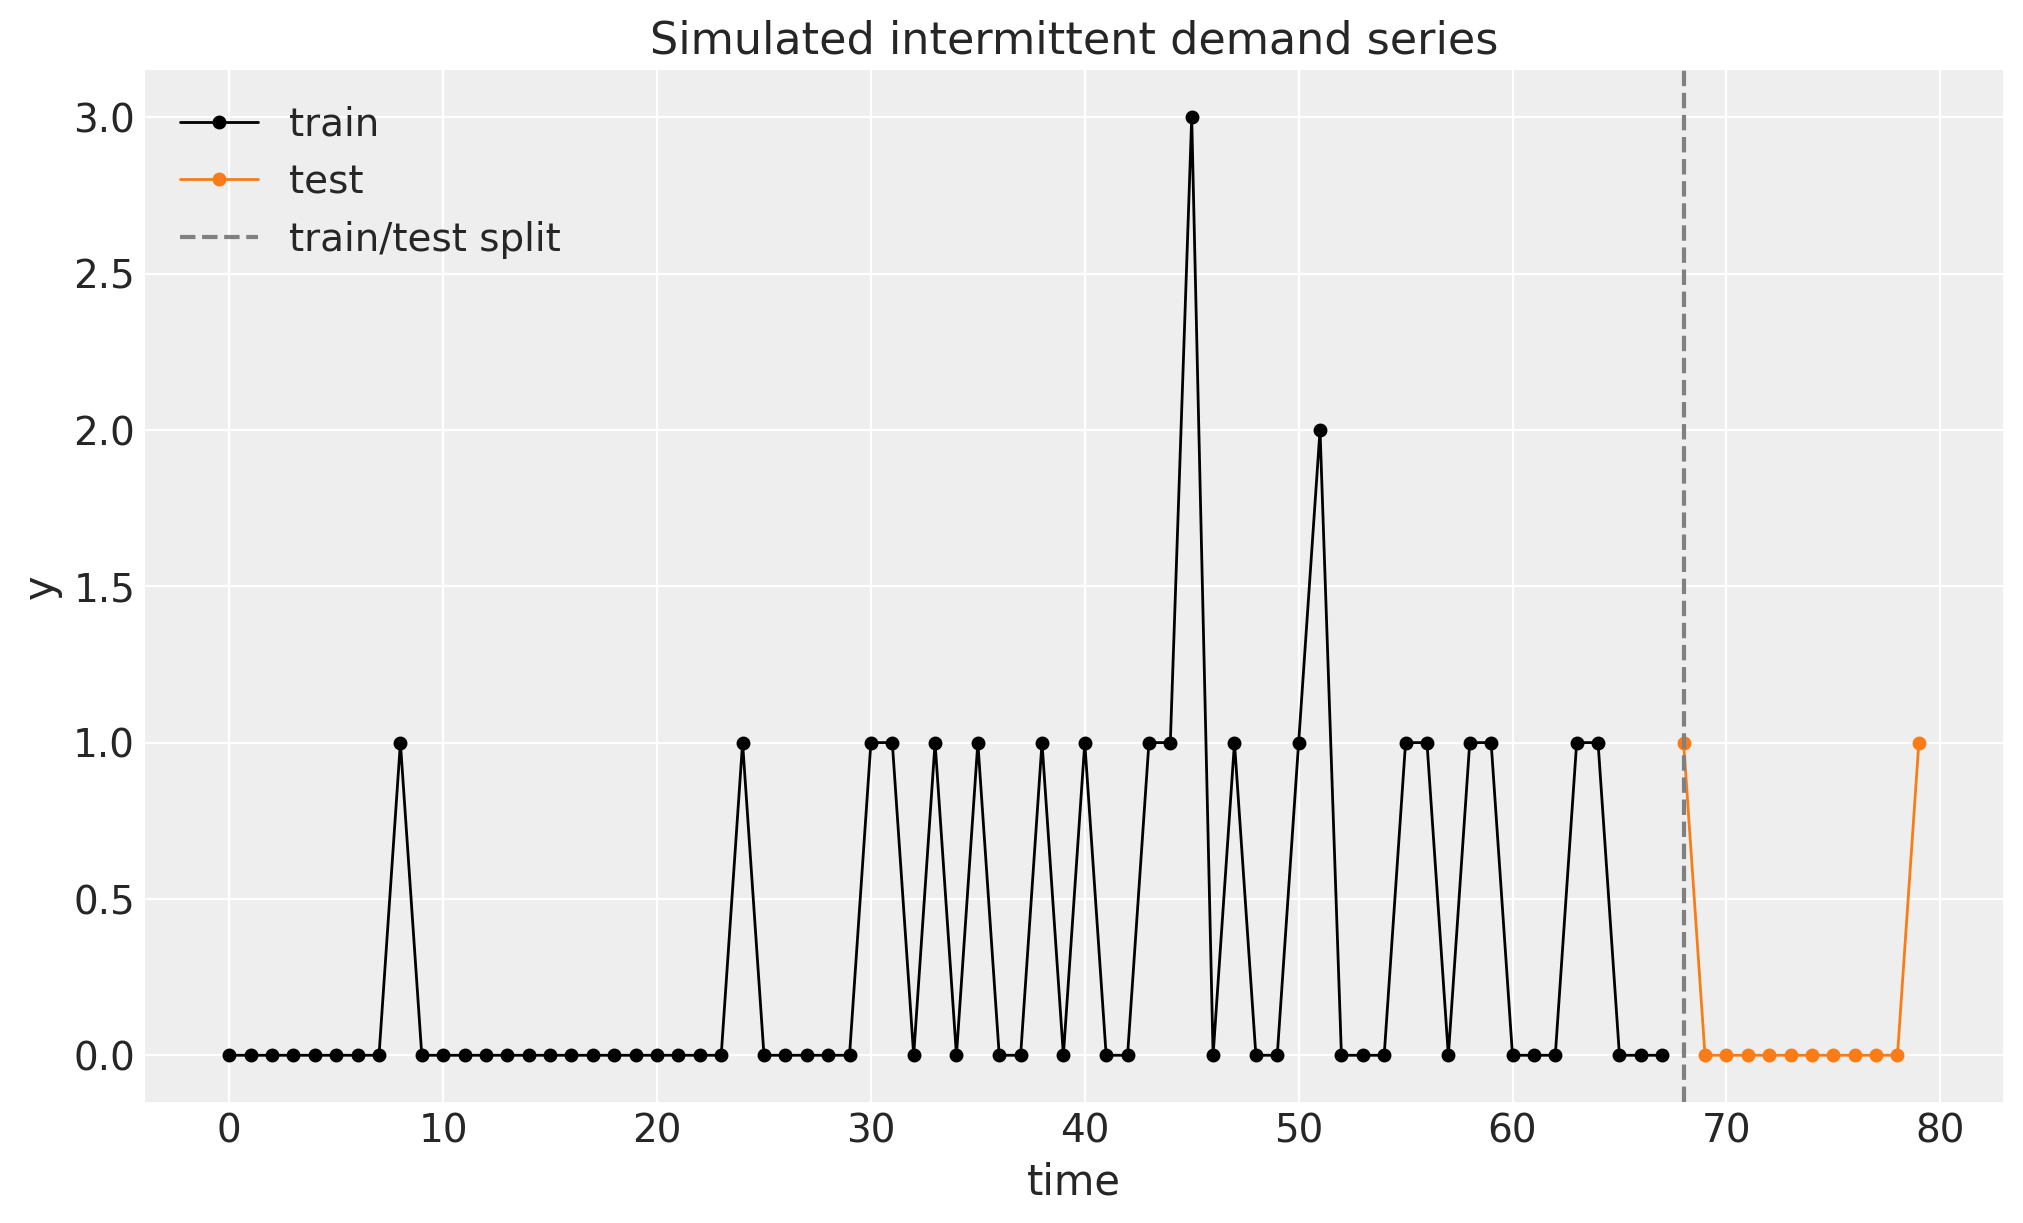

In [3]:
train_data = y_train[:, None]
test_data = y_test[:, None]
data_full = y[:, None]  # full series, used by the cross-validation at the end
covariates_train = train_data  # the demand history is the "covariate" of a TSB model
covariates_full = jnp.concatenate([y_train, jnp.zeros(n_test)])[:, None]
print(f"train data shape: {train_data.shape}, full covariates shape: {covariates_full.shape}")

fig, ax = plt.subplots()
ax.plot(t_train, y_train, "o-", color="black", lw=1, ms=4, label="train")
ax.plot(t_test, y_test, "o-", color="C1", lw=1, ms=4, label="test")
ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated intermittent demand series", xlabel="time", ylabel="y");

## Demand sizes and demand probability

The two component series TSB works with make the contrast with Croston explicit. The **demand sizes** $z$ are the non-zero values in order of appearance, exactly as in Croston. But where Croston derives the **inter-demand intervals** (one number per demand event, on the *event* axis), TSB works with the **demand indicator** $d_t = \mathbf{1}[y_t > 0]$, a $0/1$ value at *every period* on the calendar axis. Smoothing $d_t$ estimates the running probability that a period sees demand; because it is defined on every period, it can decay while zeros pile up, which is the behavior Croston's event-axis intervals cannot represent.

As in the Croston notebook this cell is exposition only: the model recomputes the indicator on the calendar axis inside its own body.

demand events in train: 20 of 68 periods
demand sizes z: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 3. 1. 1. 2. 1. 1. 1. 1. 1. 1.]
empirical demand rate (share of periods with demand): 0.294


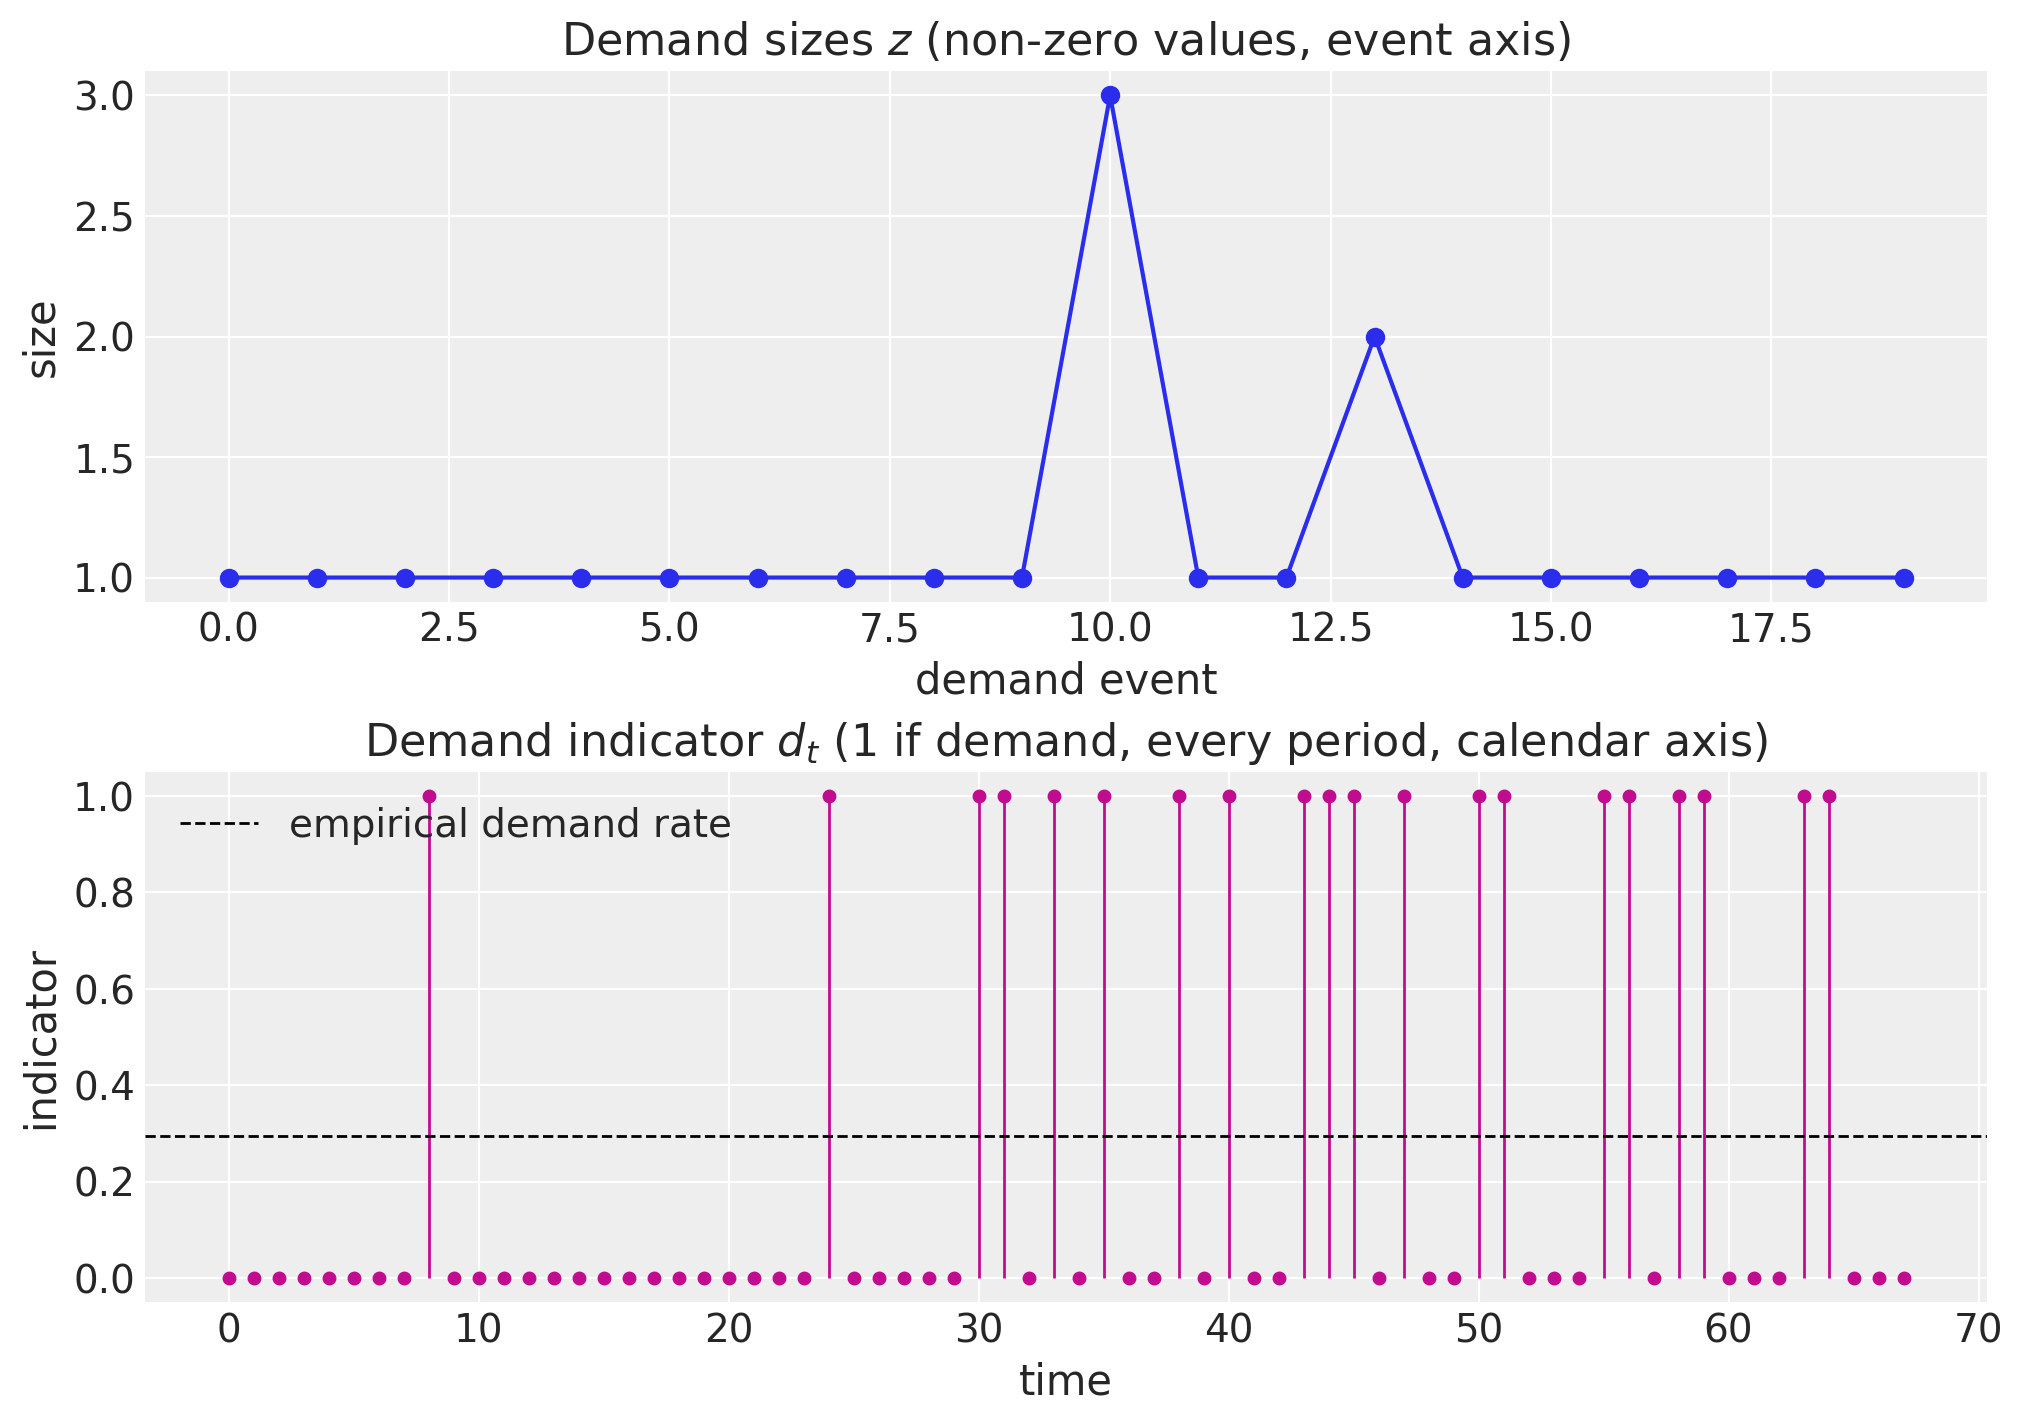

In [4]:
z = y_train[y_train != 0]
is_demand_train = np.asarray(y_train > 0)
demand_rate = float(is_demand_train.mean())

print(f"demand events in train: {z.size} of {n_train} periods")
print(f"demand sizes z: {np.asarray(z)}")
print(f"empirical demand rate (share of periods with demand): {demand_rate:.3f}")

fig, (ax_z, ax_d) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 7), sharex=False, layout="constrained"
)
ax_z.plot(np.arange(z.size), np.asarray(z), "o-", color="C0")
ax_z.set(
    title="Demand sizes $z$ (non-zero values, event axis)", xlabel="demand event", ylabel="size"
)
markerline, stemlines, baseline = ax_d.stem(t_train, is_demand_train.astype(float), basefmt=" ")
plt.setp(markerline, color="C3", markersize=4)
plt.setp(stemlines, color="C3", linewidth=1)
ax_d.axhline(demand_rate, color="black", ls="--", lw=1, label="empirical demand rate")
ax_d.legend(loc="upper left")
ax_d.set(
    title="Demand indicator $d_t$ ($1$ if demand, every period, calendar axis)",
    xlabel="time",
    ylabel="indicator",
);

## Prior for the smoothing parameters

Both components get a $\text{Beta}(2, 20)$ prior on their smoothing parameter, the *same* prior the Croston notebook uses. Its mean is $2/22 \approx 0.09$ and most of its mass sits below $0.3$, consistent with the standard practice of restricting the smoothing parameter to roughly $[0.1, 0.3]$: a level that reacts strongly to each observation produces volatile forecasts on sparse data. The blog post uses a slightly more reactive $\text{Beta}(10, 40)$ (mean $0.2$); we keep $\text{Beta}(2, 20)$ so that the *only* difference from the Croston notebook is the structural one (which recursion updates every period), not the prior.

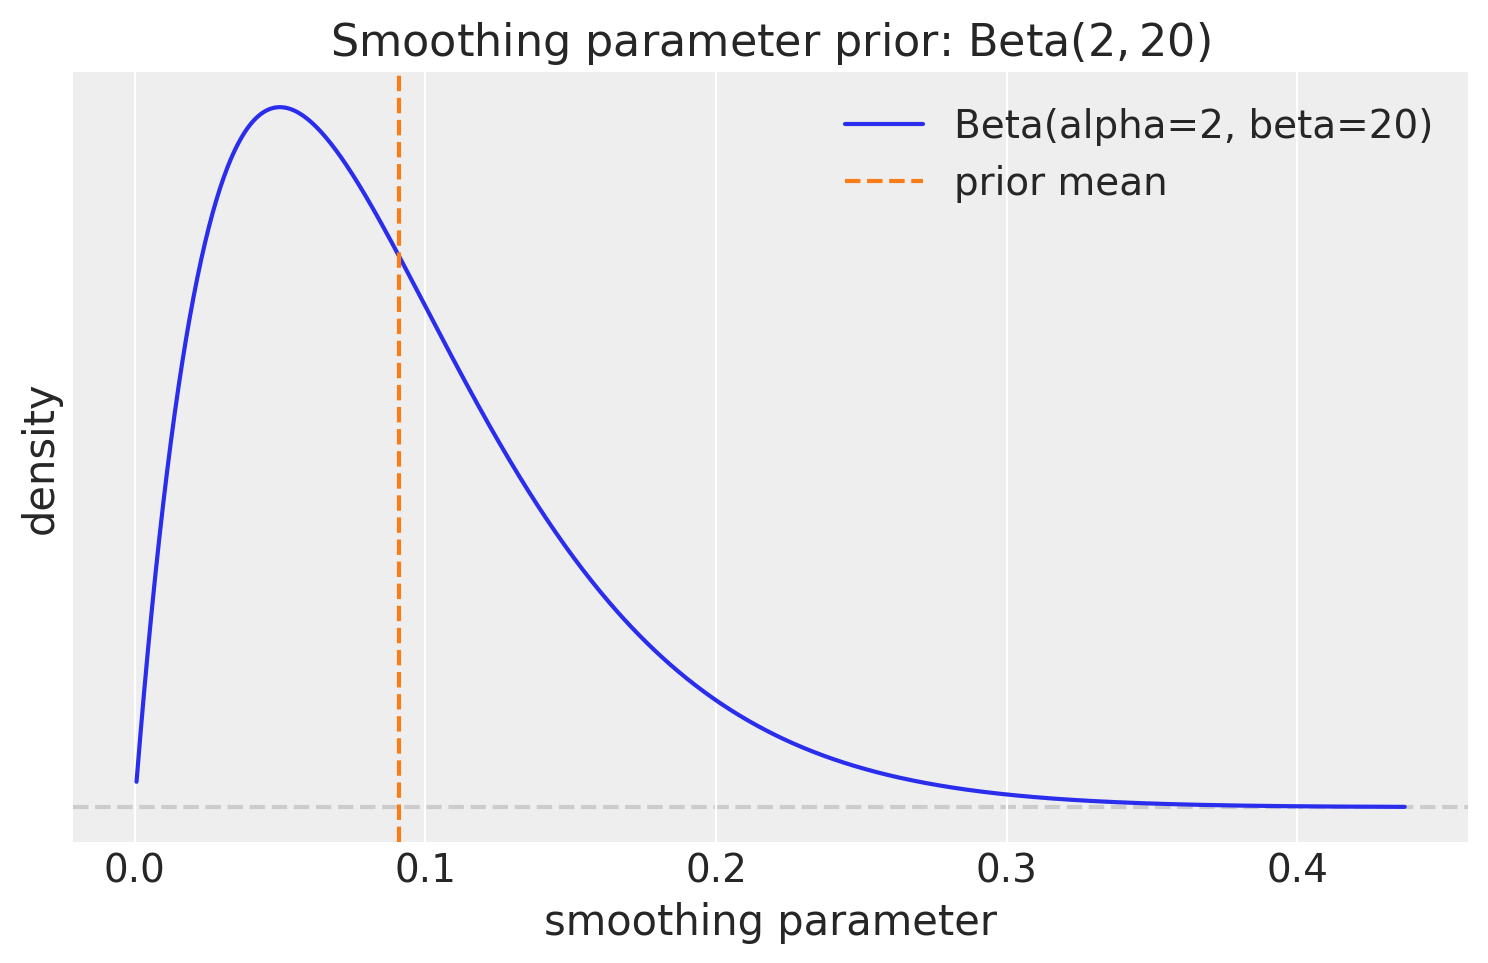

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
pz.Beta(2, 20).plot_pdf(ax=ax, color="C0")
ax.axvline(2 / 22, color="C1", ls="--", label="prior mean")
ax.legend()
ax.set(
    title=r"Smoothing parameter prior: $\text{Beta}(2, 20)$",
    xlabel="smoothing parameter",
    ylabel="density",
);

## Model specification

TSB runs **simple exponential smoothing** on each component, just like Croston. Writing $\ell_t$ for a component's level and $x_t$ for its input at time $t$, the demand-size channel updates **only at demand events**, exactly as in Croston:

$$
\ell^z_t =
\begin{cases}
\alpha_z \, y_t + (1 - \alpha_z) \, \ell^z_{t-1} & \text{if } y_t > 0, \\
\ell^z_{t-1} & \text{otherwise}.
\end{cases}
$$

The availability channel is where TSB departs. Instead of smoothing inter-demand intervals at events, it smooths the demand indicator $d_t = \mathbf{1}[y_t > 0]$ at **every period**:

$$
\ell^p_t =
\begin{cases}
\alpha_p + (1 - \alpha_p) \, \ell^p_{t-1} & \text{if } y_t > 0 \quad (\text{jump up}), \\
(1 - \alpha_p) \, \ell^p_{t-1} & \text{otherwise} \quad (\text{decay toward } 0).
\end{cases}
$$

Both branches are the single recursion $\ell^p_t = \alpha_p \, d_t + (1 - \alpha_p) \, \ell^p_{t-1}$: plain exponential smoothing of a $0/1$ series, evaluated on every period. During a run of zeros $d_t = 0$, so the probability decays by a factor $(1 - \alpha_p)$ each step; at a demand $d_t = 1$, so it jumps back up. The likelihood at each period is the one-step-ahead prediction $x_t \sim \text{Normal}(\ell_{t-1}, \sigma)$, with the size channel evaluated only at demand events (masked, as in Croston) and the probability channel evaluated at every period. The forecast is the **product** of the two levels, $\hat{y} = \hat{z} \cdot \hat{p}$: because $\hat{p} \in [0, 1]$ is used directly, there is no inversion and hence none of Croston's Jensen bias or Syntetos-Boylan correction to worry about.

Each component gets its own priors,

\begin{align*}
\alpha & \sim \text{Beta}(2, 20), \\
\ell_0 & \sim \text{Normal}(0, 1), \\
\sigma & \sim \text{HalfNormal}(1).
\end{align*}

One transparency note on the priors, sharper than in the Croston notebook: $\text{Normal}(0, 1)$ on the initial levels allows negative values, which is looser still for the probability channel, whose level is meant to live in $[0, 1]$. We keep the loose prior for comparability with the blog post and the Croston notebook; centering the probability init near the base demand rate, using a $\text{Beta}$ init, or replacing the Gaussian `obs_prob` likelihood with a $\text{Bernoulli}$ one (the indicator is, after all, a Bernoulli outcome) are the natural refinements.

Because both components run the *same* level model, we write it once and compose with NumPyro's [`scope`](https://num.pyro.ai/en/stable/handlers.html#scope) handler, exactly as the Croston notebook does. The reusable `level_model` samples the three component priors (sites `smoothing`, `init`, `noise`), runs the where-gated level recursion with a `jax.lax.scan` that emits the *pre-update* levels (the one-step-ahead means), and, when forecasting, draws the component's flat predictive at a site named `future`. Calling it under `scope(level_model, "z", divider="_")` and `scope(level_model, "p", divider="_")` yields the parameter names `z_smoothing`, `z_init`, ..., `p_future`. **This is the identical helper used in the Croston notebook**; the entire difference between the two methods is in the `tsb` body below, in a single argument.

The `tsb` body then does what is specific to TSB:

1. **Bookkeeping.** From the observed prefix of the covariates it builds the demand indicator `is_demand` and the float `demand_indicator`. Where Croston passes `is_demand` as the event gate to *both* channels, TSB passes an all-`True` gate (`every_period`) to the probability channel, so that channel updates on every period. That one substitution is the method.
2. **In sample.** The size likelihood `"obs"` is **masked** to demand events (only demand sizes inform $\ell^z$), exactly as in Croston. The probability likelihood `"obs_prob"` is **not masked**: every period's $0/1$ indicator informs $\ell^p$. The deterministic sites `"rate"` ($\ell^z_{t-1} \cdot \ell^p_{t-1}$) and `"prob"` ($\ell^p_{t-1}$) expose the fitted rate and availability for the plots below. Each level is $1$-D over time, so we index it with `[:, None]` to add the trailing observation dimension (time lives at axis $-2$ and the observation at axis $-1$ throughout the package), lining the deterministics and likelihoods up with `h.data`.
3. **Out of sample.** When `h.future > 0` the two scoped level models draw their predictives at `"z_future"` and `"p_future"`, and the body exposes their product as the `"forecast"` site the forecaster reads. As with Croston, the *multi-step* forecast is flat, but its level is the already-decayed probability at the end of training, so a forecast made right after a long drought starts lower than one made right after a demand.

In [6]:
def level_model(values: Array, is_event: Array, future: int) -> tuple[Array, Array, Array | None]:
    """Masked simple exponential smoothing level model on the calendar axis.

    Samples the component priors (sites ``smoothing``, ``init``, ``noise``), runs
    the where-gated level recursion, and, when ``future > 0``, draws the flat
    forecast predictive at the site ``future``. Meant to be called under
    :func:`numpyro.handlers.scope`, which prefixes the site names per component.
    This is the exact helper used in the Croston example; TSB differs only in the
    ``is_event`` gate it passes for the probability channel.

    Parameters
    ----------
    values
        Observed component values on the calendar axis; read only where
        ``is_event`` is true.
    is_event
        Boolean update indicator on the calendar axis; the level only updates
        where it is true (all-true for TSB's every-period probability channel).
    future
        Number of forecast steps (``0`` while training).

    Returns
    -------
    tuple[Array, Array, Array | None]
        The one-step-ahead means (the pre-update levels), the observation noise
        scale, and the forecast predictive draws (``None`` when ``future == 0``).
    """
    smoothing = numpyro.sample("smoothing", dist.Beta(concentration1=2, concentration0=20))
    init = numpyro.sample("init", dist.Normal(loc=0, scale=1))
    # jnp.asarray only narrows numpyro's union return type for the type checker.
    noise = jnp.asarray(numpyro.sample("noise", dist.HalfNormal(scale=1)))

    def transition_fn(carry, inputs):
        x_t, event_t = inputs
        level = jnp.where(event_t, smoothing * x_t + (1 - smoothing) * carry, carry)
        # Emit the pre-update level: the one-step-ahead mean.
        return level, carry

    last_level, mu = jax.lax.scan(transition_fn, init, (values, is_event))

    future_draws = None
    if future > 0:
        # jnp.asarray only narrows numpyro's union return type for the type checker.
        future_draws = jnp.asarray(
            numpyro.sample(
                "future", dist.Normal(loc=last_level, scale=noise).expand([future]).to_event(1)
            )
        )
    return mu, noise, future_draws


def tsb(h: Horizon, covariates: Array) -> None:
    """TSB's method as two scoped exponential smoothing level models.

    Identical to the Croston body except the probability channel smooths the
    demand indicator at *every* period (``every_period`` gate, unmasked
    likelihood) instead of inter-demand intervals at demand events only.

    Parameters
    ----------
    h
        The train/forecast horizon for the current model call.
    covariates
        The observed demand series itself, with time at axis ``-2``; only the
        first ``h.t_obs`` rows are read.
    """
    y_obs = covariates[..., : h.t_obs, 0]  # observed history only; never reads beyond t_obs
    is_demand = y_obs > 0
    demand_indicator = is_demand.astype(y_obs.dtype)
    every_period = jnp.ones_like(is_demand)  # TSB updates the probability at EVERY period

    # Demand-size channel: byte-for-byte identical to Croston (updates only at demand events).
    z_mu, z_noise, z_future = scope(level_model, "z", divider="_")(y_obs, is_demand, h.future)
    # Availability channel: smooths the 0/1 indicator every period (the one structural change).
    p_mu, p_noise, p_future = scope(level_model, "p", divider="_")(
        demand_indicator, every_period, h.future
    )

    # z_mu and p_mu are 1-D over time; [:, None] adds the trailing observation dim
    # (axis -1) so every site matches the package's (time, obs) layout and h.data.
    numpyro.deterministic("rate", (z_mu * p_mu)[:, None])
    numpyro.deterministic("prob", p_mu[:, None])
    numpyro.sample(
        "obs",
        dist.Normal(loc=z_mu[:, None], scale=z_noise).mask(is_demand[:, None]),
        obs=h.data,
    )
    numpyro.sample(
        "obs_prob",
        dist.Normal(loc=p_mu[:, None], scale=p_noise),  # not masked: every period contributes
        obs=demand_indicator[:, None],
    )

    if z_future is not None and p_future is not None:  # exactly when h.future > 0
        numpyro.deterministic("z_forecast", z_future[:, None])
        numpyro.deterministic("p_forecast", p_future[:, None])
        numpyro.deterministic("forecast", (z_future * p_future)[:, None])


model = forecasting_model(tsb)

## Inference with NUTS

We fit the model on the training window with the No-U-Turn Sampler through the functional [`fit_mcmc`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.mcmc.fit_mcmc.html), running $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps each. As in Croston the posterior has six scalar parameters, three per component.

We then export the fit into an ArviZ-schema `xarray.DataTree` with [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html). Because we pass the *extended* covariates, the tree automatically carries `predictions` groups with the out-of-sample forecast draws. We register both per-timestep deterministics, `"rate"` and `"prob"`, so they share the tree-wide `time` coordinate.

In [7]:
rng_key, rng_subkey = random.split(rng_key)
fit = fit_mcmc(
    rng_subkey,
    model,
    train_data,
    covariates_train,
    num_warmup=1_000,
    num_samples=1_000,
    num_chains=4,
)

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    fit,
    model,
    train_data,
    covariates_full,
    posterior_dims={"rate": ["time", "obs_dim"], "prob": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:      (chain: 4, draw: 1000, time: 68, obs_dim: 1)
│       Coordinates:
│         * chain        (chain) int64 32B 0 1 2 3
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * time         (time) int64 544B 0 1 2 3 4 5 6 7 8 ... 60 61 62 63 64 65 66 67
│         * obs_dim      (obs_dim) int64 8B 0
│       Data variables:
│           p_init       (chain, draw) float32 16kB -0.003375 0.1119 ... 0.4061 -0.2237
│           p_noise      (chain, draw) float32 16kB 0.4995 0.4072 ... 0.517 0.5237
│           p_smoothing  (chain, draw) float32 16kB 0.05509 0.103 ... 0.08918 0.1302
│           prob         (chain, draw, time, obs_dim) float32 1MB -0.003375 ... 0.4051
│           rate         (chain, draw, time, obs_dim) float32 1MB -0.002591 ... 0.4869
│           z_init       (chain, draw) float32 16kB 0.7678 1.256 0.8319 ... 1.074 1.281
│           z_noise      (chain, draw) float32 16kB 0.4392 0.572 ... 0.5041 0.6103
│           z_smoothing  (chain, draw) float32 16kB 0.1112 0.03419 ... 0.05288 0.04834
│       Attributes:
│           created_at:                 2026-07-21T09:55:30.474899+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 68, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 544B 0 1 2 3 4 5 6 7 8 ... 59 60 61 62 63 64 65 66 67
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 1MB 1.319 0.2379 ... -0.1558
│       Attributes:
│           created_at:                 2026-07-21T09:55:30.616382+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 68, obs_dim: 1)
│       Coordinates:
│         * time     (time) int64 544B 0 1 2 3 4 5 6 7 8 ... 59 60 61 62 63 64 65 66 67
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (time, obs_dim) float32 272B 0.0 0.0 0.0 0.0 ... 1.0 0.0 0.0 0.0
│       Attributes:
│           created_at:                 2026-07-21T09:55:30.616627+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (time: 68, covariate_dim: 1)
│       Coordinates:
│         * time           (time) int64 544B 0 1 2 3 4 5 6 7 ... 60 61 62 63 64 65 66 67
│         * covariate_dim  (covariate_dim) int64 8B 0
│       Data variables:
│           covariates     (time, covariate_dim) float32 272B 0.0 0.0 0.0 ... 0.0 0.0
│       Attributes:
│           created_at:                 2026-07-21T09:55:30.616799+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /predictions
│       Dimensions:  (chain: 4, draw: 1000, time: 12, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 96B 68 69 70 71 72 73 74 75 76 77 78 79
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, t

## Diagnostics

`az.summary` on the six scalar parameters gives the convergence picture in one call: posterior means and standard deviations, the $94\%$ HDIs, effective sample sizes, and $\hat{R}$.

In [8]:
scalar_vars = [
    "z_smoothing",
    "z_init",
    "z_noise",
    "p_smoothing",
    "p_init",
    "p_noise",
]
az.summary(tree, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z_smoothing,0.086,0.056,0.012,0.22,3655,2549,1.00,0.00092,0.0009
z_init,1.065,0.234,0.57,1.5,3180,2178,1.00,0.0043,0.0037
z_noise,0.537,0.091,0.39,0.74,4248,2529,1.00,0.0015,0.0013
p_smoothing,0.094,0.039,0.033,0.18,3787,2438,1.00,0.0006,0.00049
p_init,0.091,0.197,-0.3,0.44,3674,2484,1.00,0.0033,0.0023
p_noise,0.459,0.0416,0.39,0.54,5695,2923,1.00,0.00056,0.00042


The chains mix well: the $\hat{R}$ values are essentially $1$ and the effective sample sizes are healthy. The demand-size parameters (`z_smoothing`, `z_init`, `z_noise`) reproduce the Croston picture, because that channel is unchanged: the smoothing posterior barely moves from the $\text{Beta}(2, 20)$ prior, while the initial level concentrates near the typical demand size of about $1$. The probability channel tells the more interesting story. Its smoothing posterior also stays low, which is the correct answer for this *stationary* series: an i.i.d. demand process has no genuine trend in its occurrence rate, so smoothing slowly and tracking the base rate is exactly right. Its initial level and noise scale come out slightly tighter than their demand-size counterparts (`p_init` and `p_noise` have smaller standard deviations than `z_init` and `z_noise`), because the indicator gives the probability channel one observation on every one of the $68$ periods, against the $20$ demand events the size channel sees. The trace plots confirm the picture.

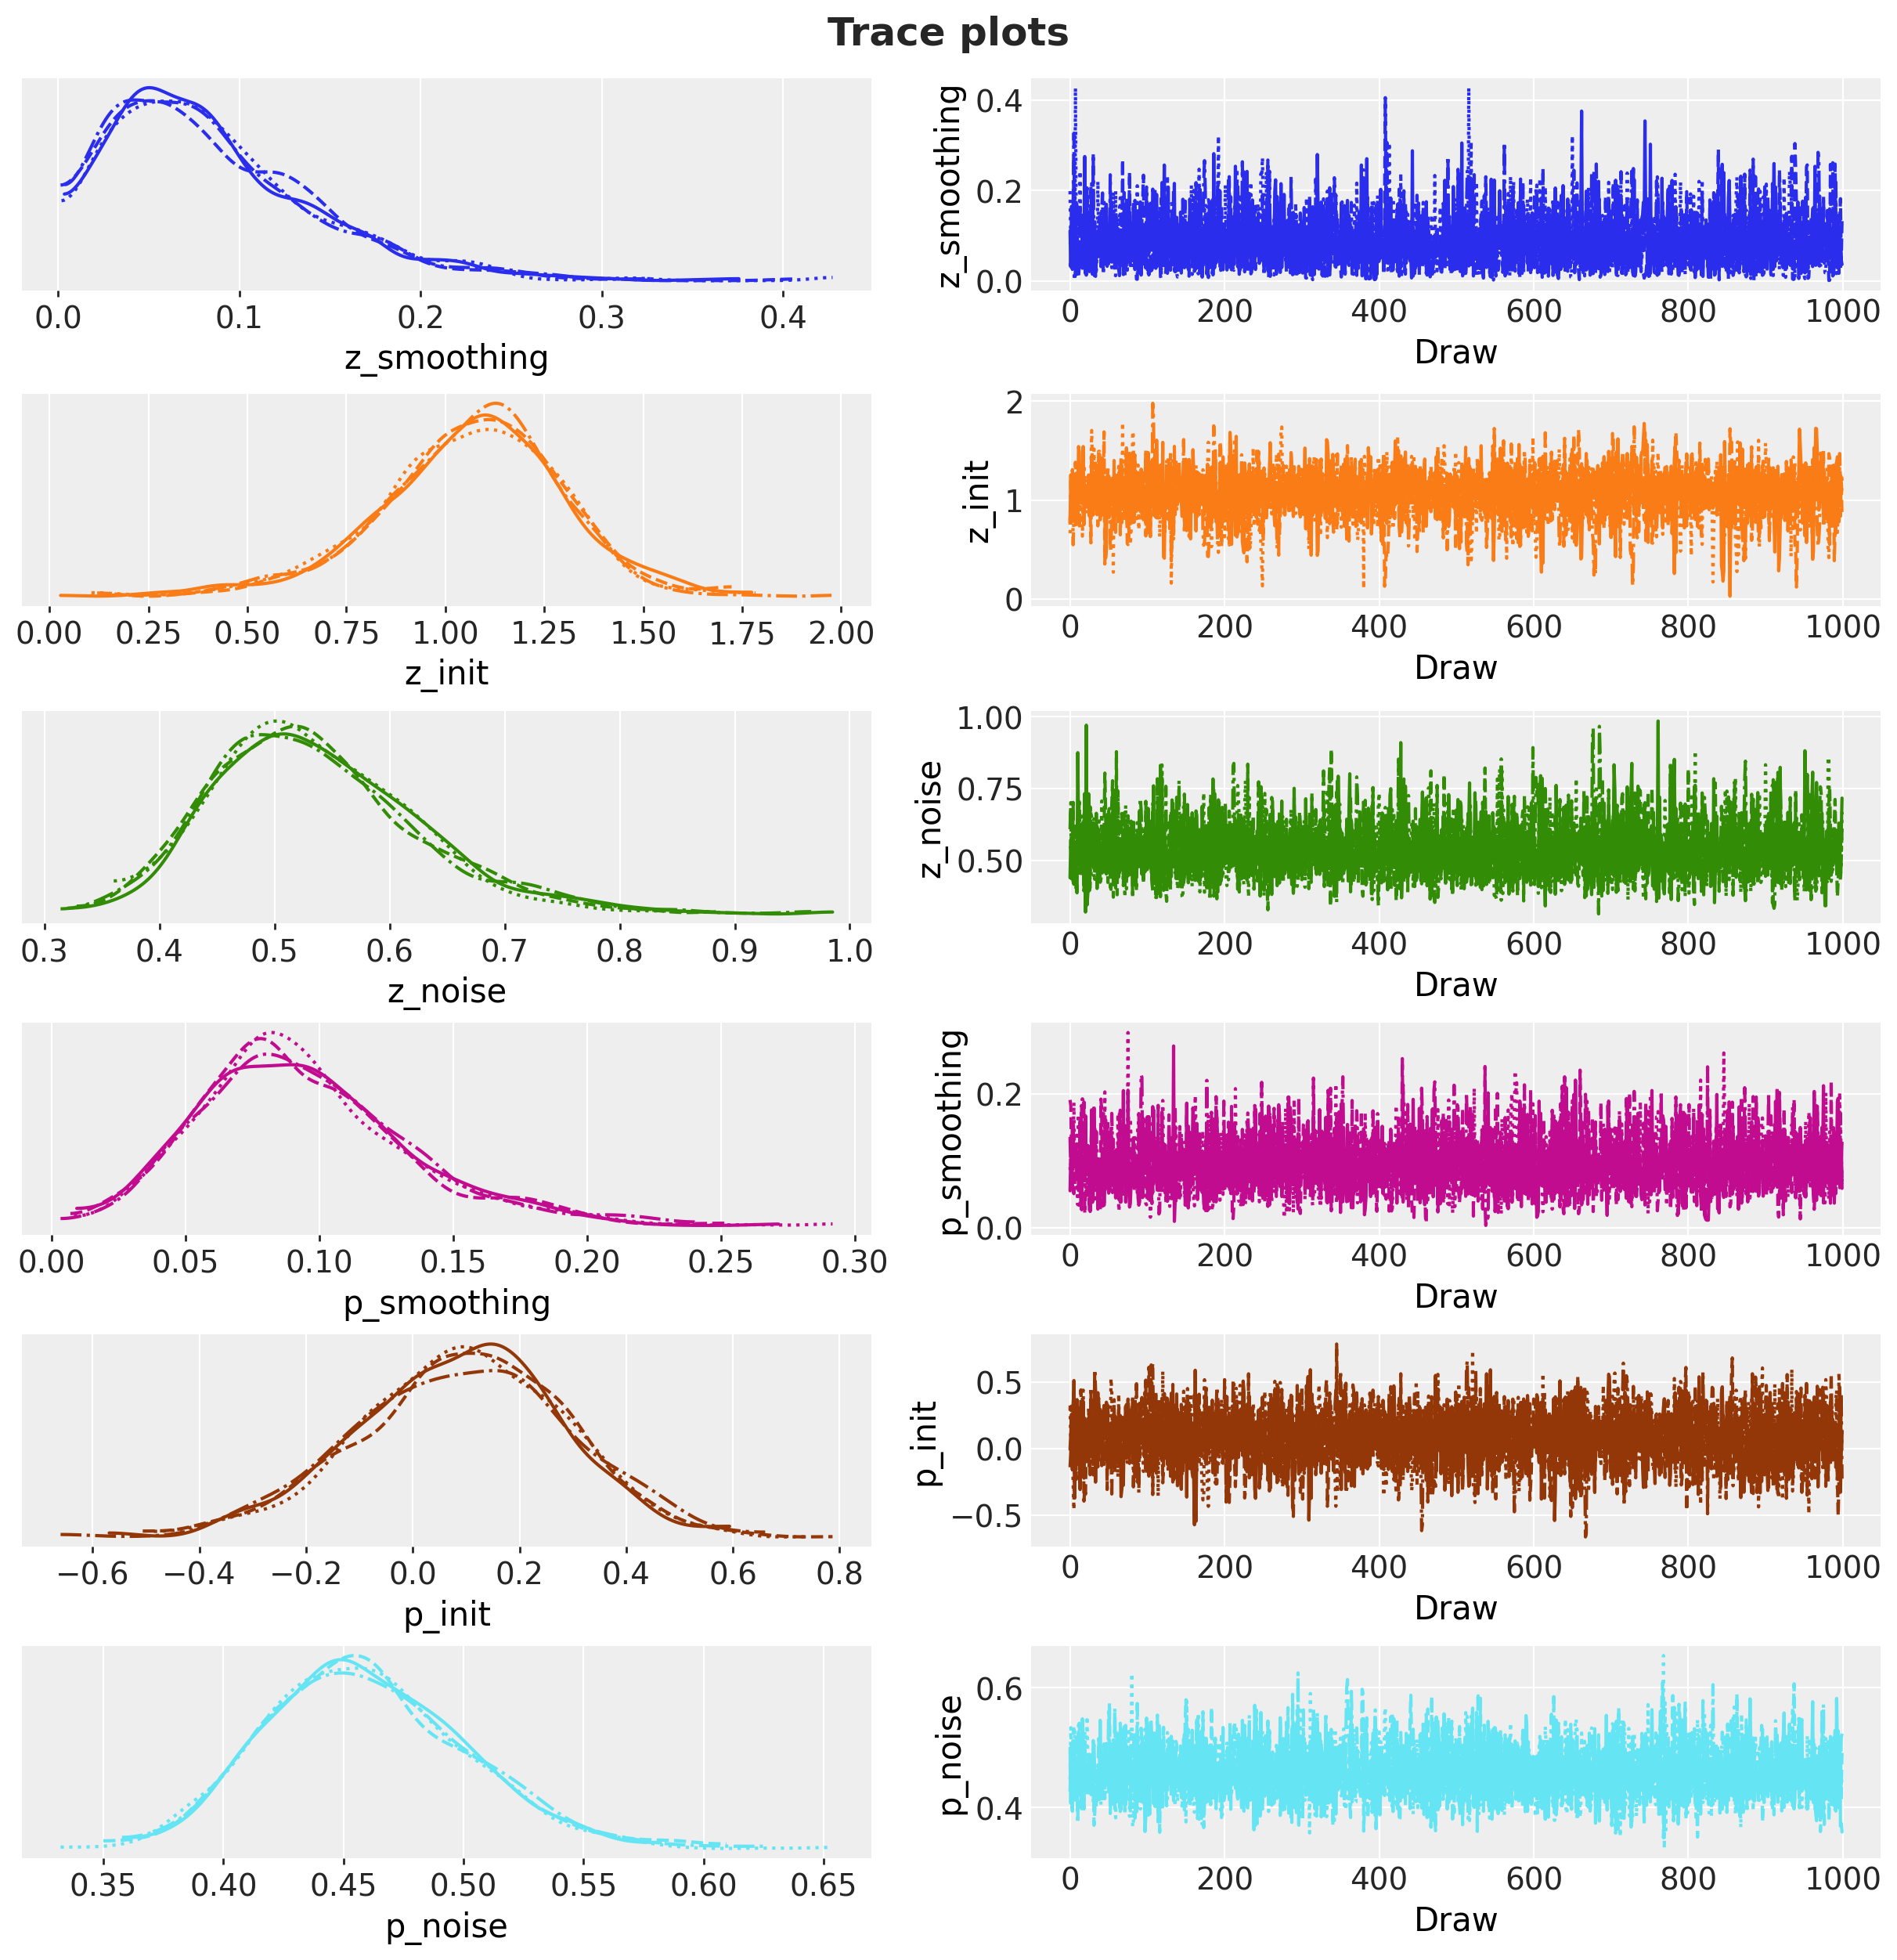

In [9]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    compact=True,
    figure_kwargs={"figsize": (12, 12)},
)
pc_trace.viz["figure"].item().suptitle(
    "Trace plots",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## In-sample fit

For the in-sample story we plot the posterior of the deterministic `"rate"` site: the running TSB fitted rate $\ell^z_{t-1} \cdot \ell^p_{t-1}$, the expected demand per period given the history so far. Compared with the Croston rate, which is piecewise constant and can only step at demand events, the TSB rate is visibly **alive between demands**: because the availability probability decays on every zero, the rate slopes downward through each run of zeros and jumps back up at the next demand. That sawtooth is the signature of the every-period update, and it is the single clearest picture of how TSB differs from Croston. This cell also defines the small plotting helpers (`stacked_draws` and `plot_band_forecast`) shared by the remaining band plots.

The same caveat as in the Croston notebook applies: the tree's `posterior_predictive` group (the `"obs"` site) carries the *masked demand-size* likelihood, so its draws describe the size of a demand given that one occurs and are not comparable to the raw, mostly-zero series. This is why the cross-validation below scores only out-of-sample forecasts (`eval_train=False`).

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


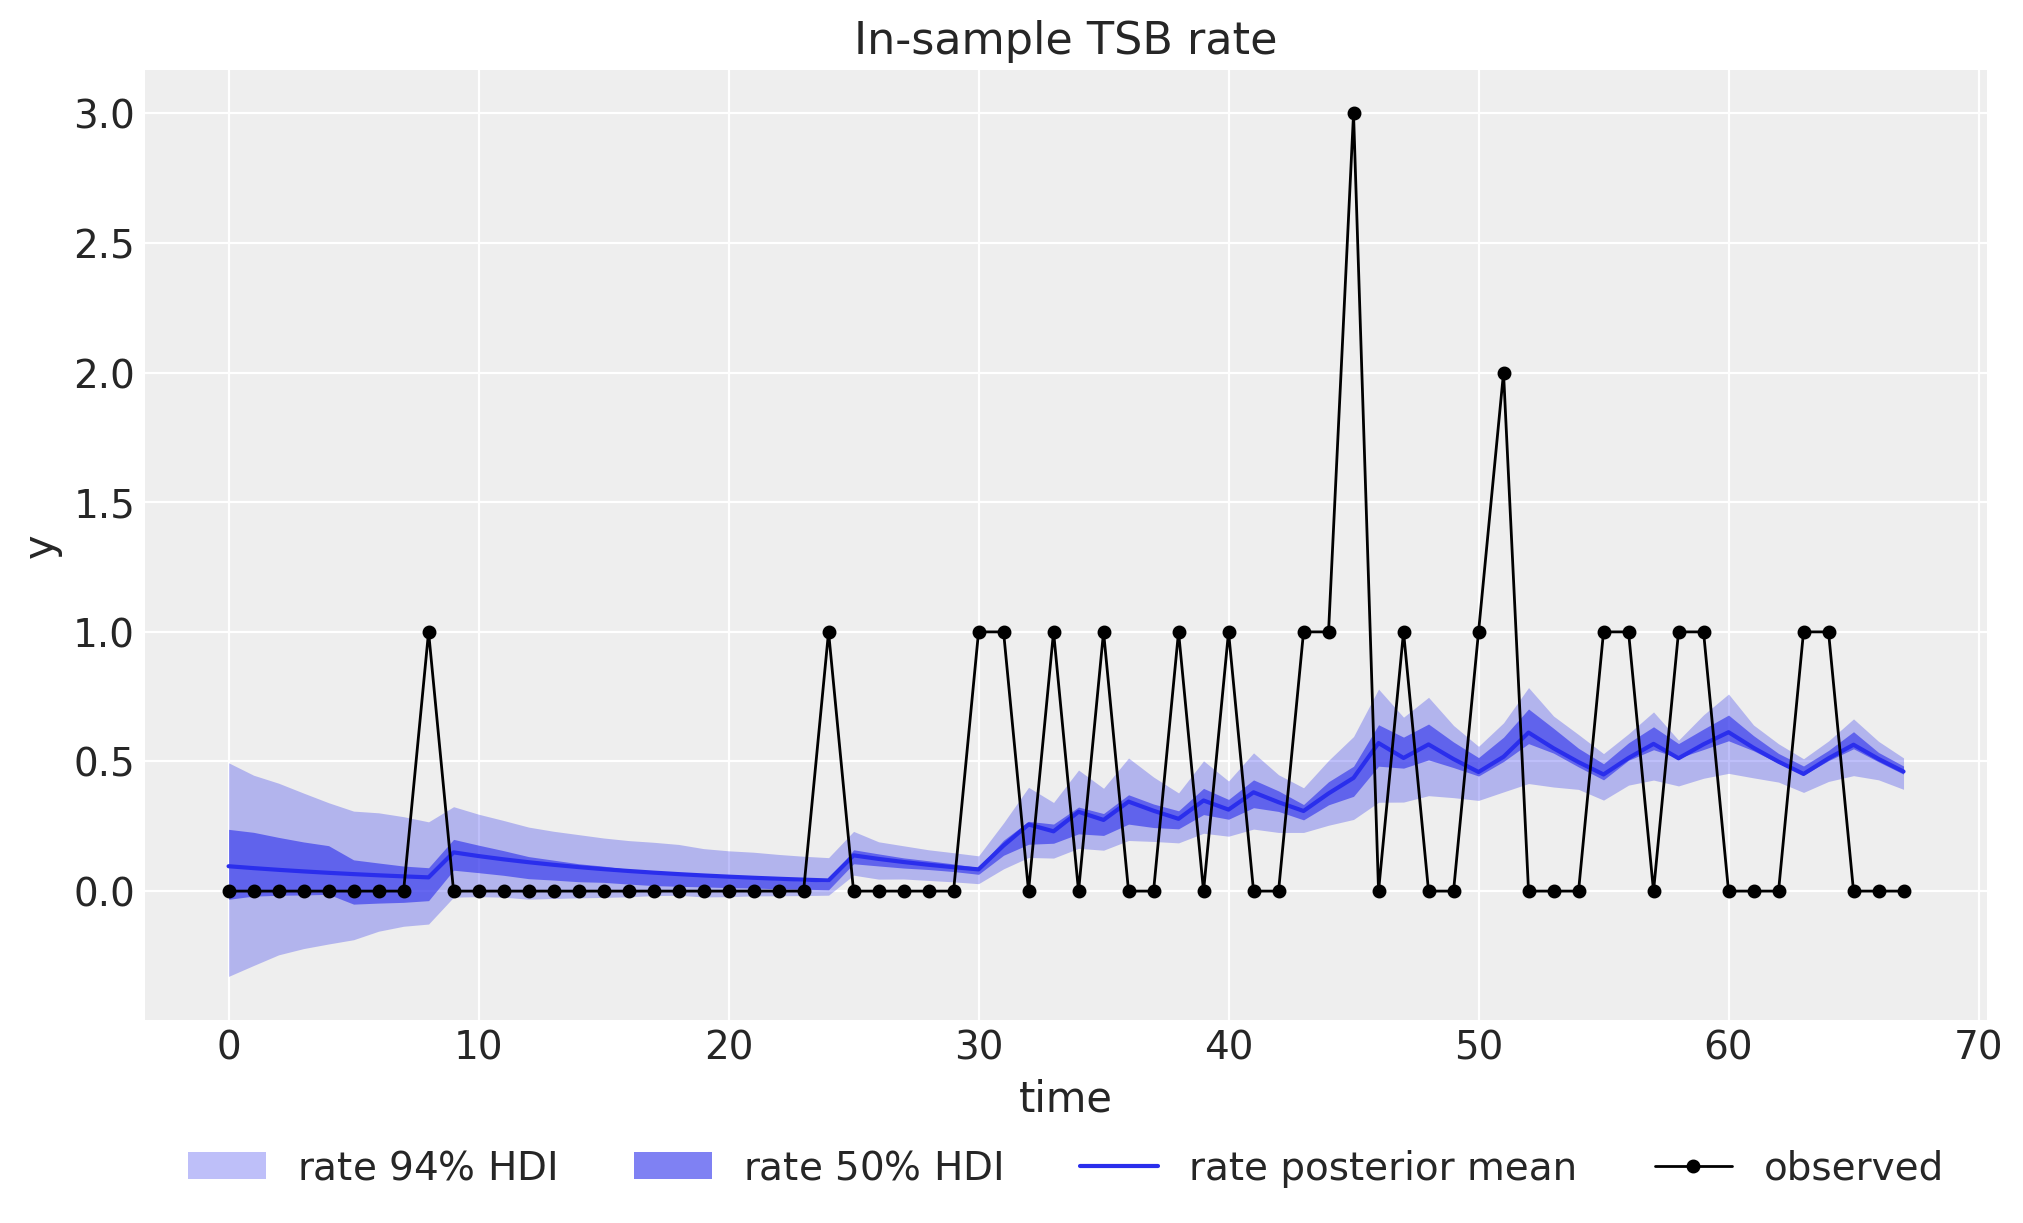

In [10]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter


def stacked_draws(group: xr.DataTree | xr.DataArray, var: str) -> np.ndarray:
    """Stack a tree variable's ``(chain, draw)`` dims into a leading sample axis.

    Parameters
    ----------
    group
        A tree group holding ``var`` with dims ``(chain, draw, time, obs_dim)``
        (typed as the union ``tree[...]`` returns; a group always arrives here).
    var
        Name of the variable to extract.

    Returns
    -------
    np.ndarray
        The draws with shape ``(sample, time, obs_dim)``.
    """
    return (
        group.dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


def plot_band_forecast(
    draws: np.ndarray,
    x: np.ndarray,
    color: str,
    label_prefix: str = "",
    observed: Array | np.ndarray | None = None,
    figsize: tuple[float, float] = (12.0, 6.0),
) -> tuple[Axes, list[Artist]]:
    r"""Plot the posterior mean line and the $50\%$/$94\%$ HDI bands of ``draws``.

    Wraps ``predictions_to_datatree`` and ``az.plot_lm`` with the notebook-wide
    band styling (inner band darker via ``hdi_alphas``) and labels the artists.
    Overlays (observed series, split lines, extra point estimates) and the
    legend are the caller's responsibility.

    Parameters
    ----------
    draws
        Predictive draws with shape ``(sample, time, 1)``.
    x
        Numeric x values of length ``time``.
    color
        Matplotlib color for the bands and the mean line.
    label_prefix
        Prefix for the legend labels, e.g. ``"forecast "``.
    observed
        Optional observed data stored alongside the draws.
    figsize
        Figure size passed to ``plot_lm``.

    Returns
    -------
    tuple[Axes, list[Artist]]
        The axes and the labeled band and mean-line handles for the legend.
    """
    idata = predictions_to_datatree(draws, x, ["y"], observed=observed)
    pc = az.plot_lm(
        idata,
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        point_estimate="mean",
        visuals={
            "ci_band": {"color": color},
            "observed_scatter": False,
            "pe_line": {"color": color, "alpha": 1.0, "width": 1.5},
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": figsize},
    )
    bands = pc.viz["ci_band"]["t"]
    band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
    band_94.set_label(hdi_label(0.94, prefix=label_prefix))
    band_50.set_label(hdi_label(0.5, prefix=label_prefix))
    pe_line = pc.viz["pe_line"]["t"].item()
    pe_line.set_label(f"{label_prefix}posterior mean")
    ax = pc.viz["figure"].item().axes[0]
    return ax, [band_94, band_50, pe_line]


rate_draws = stacked_draws(tree["posterior"], "rate")

ax, handles = plot_band_forecast(
    rate_draws,
    t_train.astype(float),
    "C0",
    label_prefix="rate ",
    observed=train_data,
    figsize=(10.0, 6.0),
)
(obs_line,) = ax.plot(
    t_train, np.asarray(y_train), "o-", color="black", lw=1, ms=4, label="observed"
)
ax.legend(
    handles=[*handles, obs_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)
ax.set(title="In-sample TSB rate", xlabel="time", ylabel="y");

### The availability probability

The rate above is a product of two levels; the availability probability $\ell^p$ is the component that carries all of the TSB behavior, so it is worth looking at on its own. The plot below is the posterior of the `"prob"` site against the demand-event times (the rug at the bottom) and the empirical demand rate (dashed line).

Two things stand out. First, the probability path **decays through every run of zeros and jumps at each demand**, oscillating around the base rate: this is precisely the per-period responsiveness Croston lacks, where the interval channel would hold a flat line across the same zeros. Second, the amount of decay per zero is governed by $\alpha_p$, and with the low posterior smoothing the per-step change is small: within a single short gap the probability barely moves, but across the sparse first third of the series the drops accumulate and pull it down toward zero, and it climbs back to oscillate around the base rate once demands arrive frequently. On this *stationary* series that gentle, base-rate-tracking behavior is the honest answer, because there is no real trend in the occurrence rate to chase. The mechanism that produces the sawtooth is exactly the mechanism that would let the forecast fall toward zero if demand genuinely dried up, which is what makes TSB the right tool when obsolescence is a real possibility.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


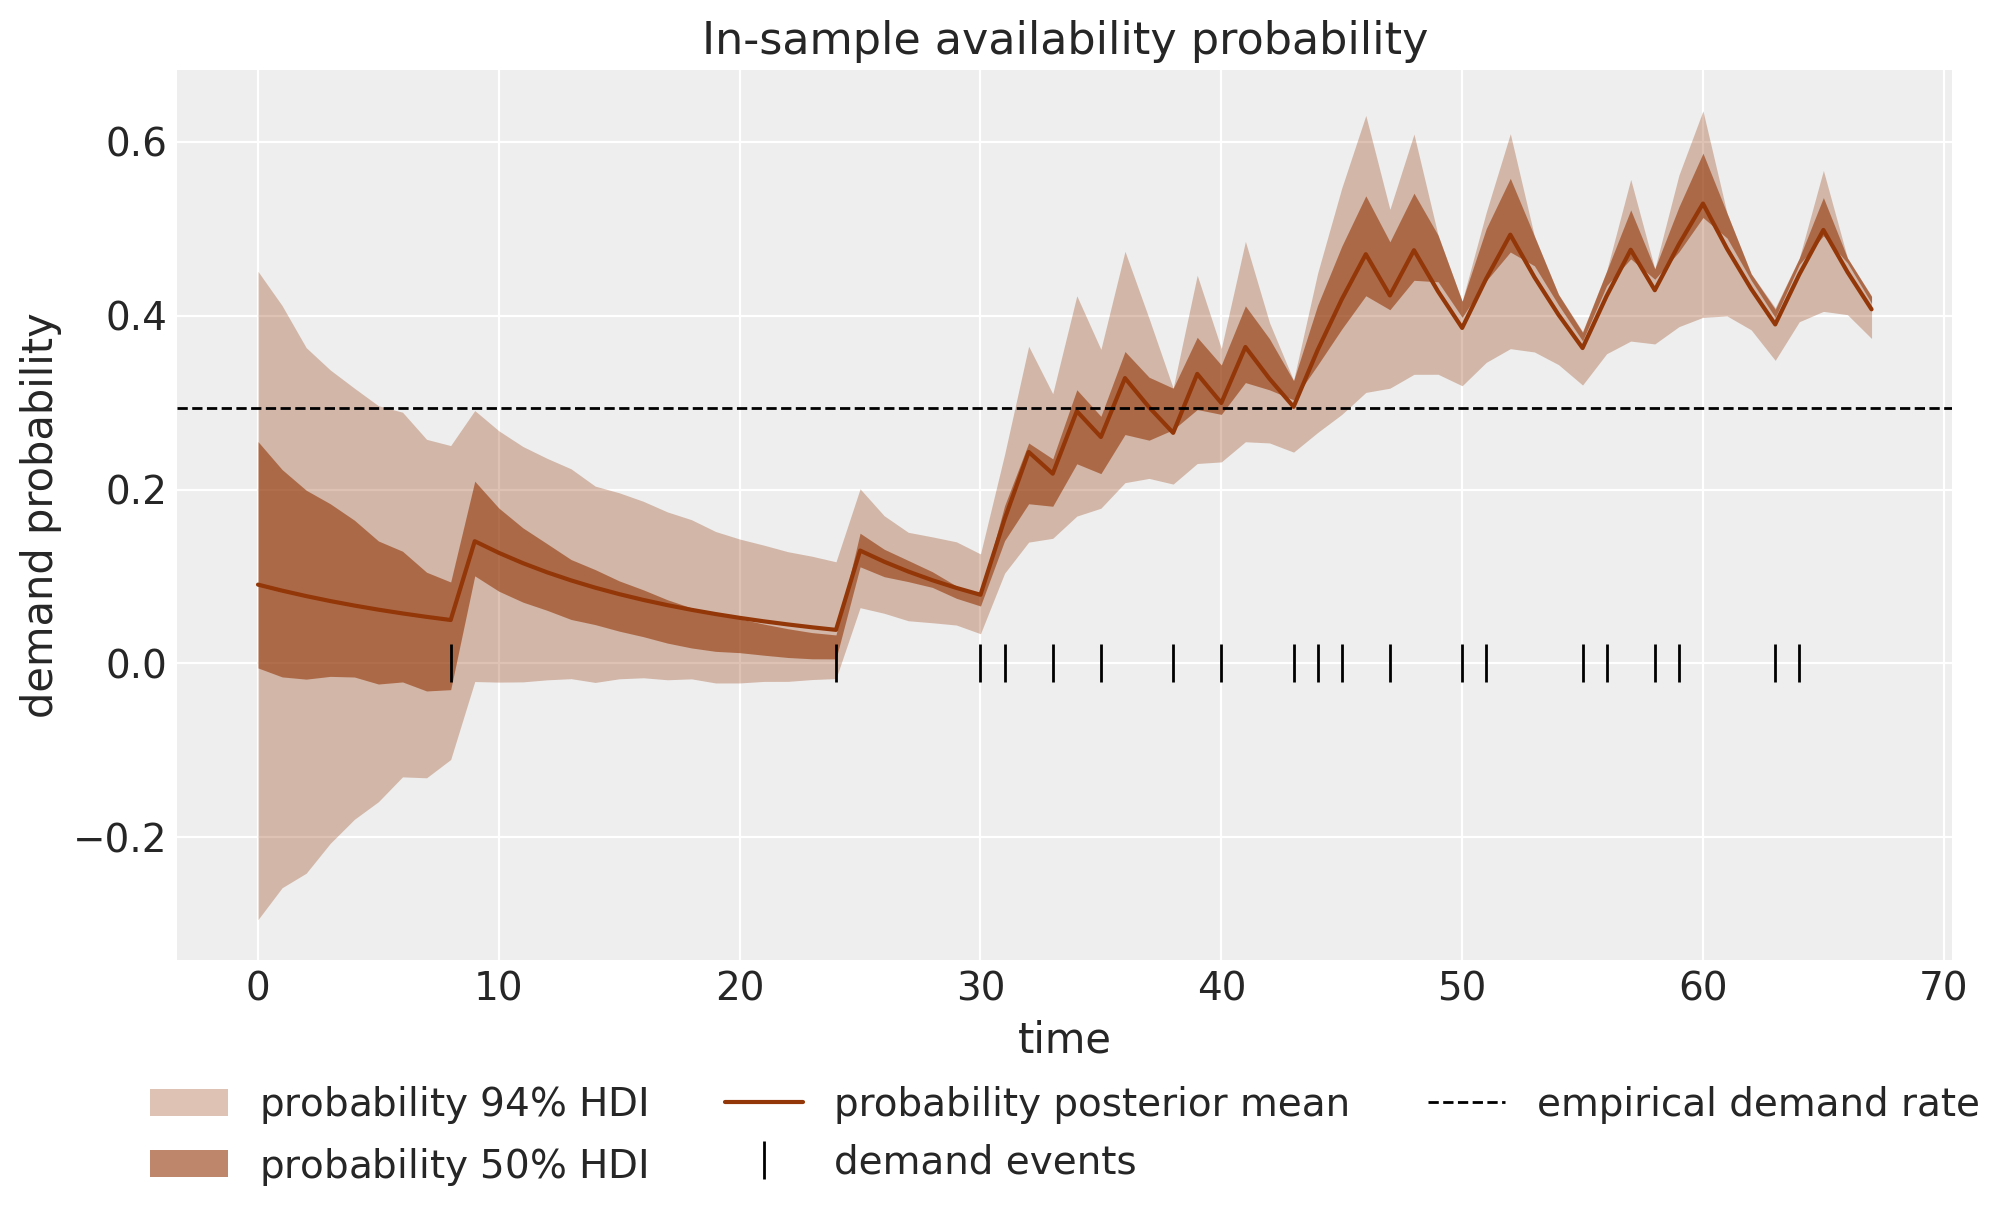

In [11]:
prob_draws = stacked_draws(tree["posterior"], "prob")

ax, handles = plot_band_forecast(
    prob_draws,
    t_train.astype(float),
    "C4",
    label_prefix="probability ",
    figsize=(10.0, 6.0),
)
event_times = t_train[is_demand_train]
(rug,) = ax.plot(
    event_times,
    np.zeros_like(event_times, dtype=float),
    "|",
    color="black",
    ms=14,
    label="demand events",
)
base_line = ax.axhline(demand_rate, color="black", ls="--", lw=1, label="empirical demand rate")
ax.legend(
    handles=[*handles, rug, base_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="In-sample availability probability", xlabel="time", ylabel="demand probability");

## Forecast

The `predictions` group of the tree already holds the out-of-sample draws of the `"forecast"` site over the test window: the product of the two components' predictive samples. We plot the posterior mean and median together with the $50\%$ and $94\%$ HDI bands against the held-out data, and score the forecast with the CRPS (lower is better).

Like Croston, the *multi-step* forecast is **flat**: with no future observations the levels stay put, so TSB predicts the same demand rate for every horizon step. The difference is where that flat level comes from. It starts from the availability probability *as of the end of the training window*, which here is relatively high because training ends in a demand-dense stretch; had it ended in a long drought, the forecast would start proportionally lower. That sensitivity to how recently demand was seen is exactly what the one-step-ahead cross-validation below makes visible. The predictive is right-skewed (the solid mean sits above the dashed median), and because the probability channel is a Gaussian centered on a small value, a sizable share of its draws fall below zero: the inner $50\%$ band already dips under the axis. This is the same pragmatic Normal-likelihood choice as the blog post, and modeling the indicator with a $\text{Bernoulli}$ likelihood (or the size with a truncated or log-normal one) is the natural fix.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


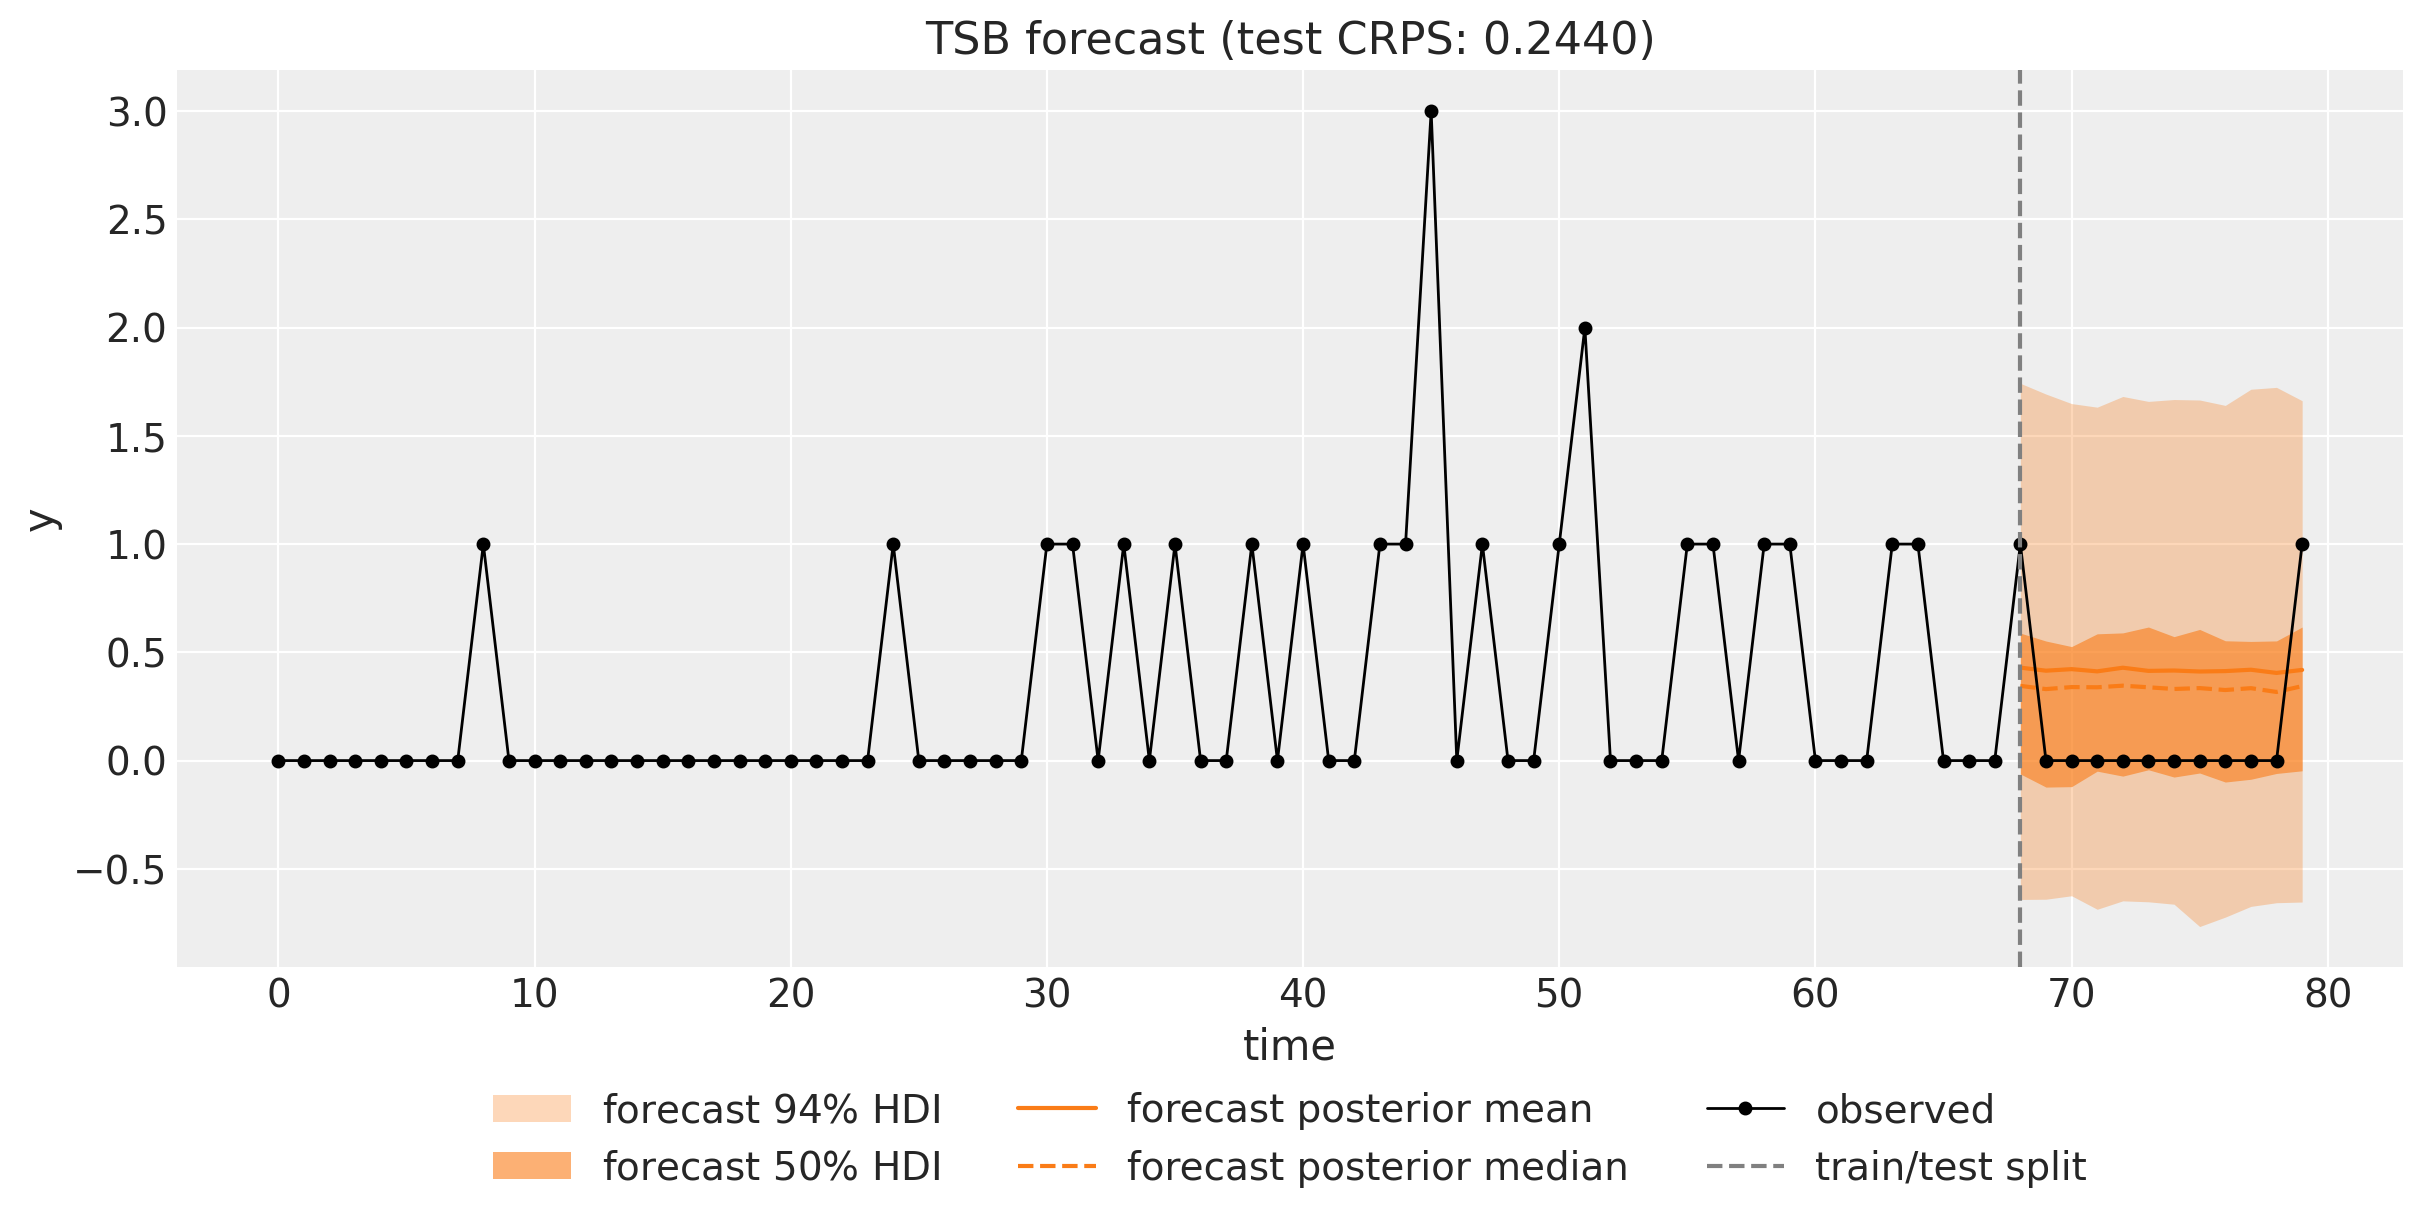

In [12]:
forecast_pp = stacked_draws(tree["predictions"], "obs")
crps_test = eval_crps(forecast_pp, test_data)

ax, handles = plot_band_forecast(
    forecast_pp, t_test.astype(float), "C1", label_prefix="forecast ", observed=test_data
)
(median_line,) = ax.plot(
    t_test,
    np.median(forecast_pp[..., 0], axis=0),
    color="C1",
    ls="--",
    lw=1.5,
    label="forecast posterior median",
)
(obs_line,) = ax.plot(t, np.asarray(y), "o-", color="black", lw=1, ms=4, label="observed")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, median_line, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"TSB forecast (test CRPS: {crps_test:.4f})",
    xlabel="time",
    ylabel="y",
);

### Component forecasts

To see where the combined forecast comes from, we sample the two component predictives directly with `Predictive`, requesting the `"z_forecast"` and `"p_forecast"` deterministic sites, and plot them side by side with a single faceted `plot_lm` call. The demand-size component predicts the size of the next demand; the demand-probability component predicts the chance a period sees any demand at all. Their product is the forecast above. The probability component targets a quantity in $[0, 1]$, unlike Croston's unbounded inverse interval, though our Gaussian likelihood still lets some predictive draws stray outside that range, one more reason a $\text{Bernoulli}$ or $\text{Beta}$ probability channel is the natural next step.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


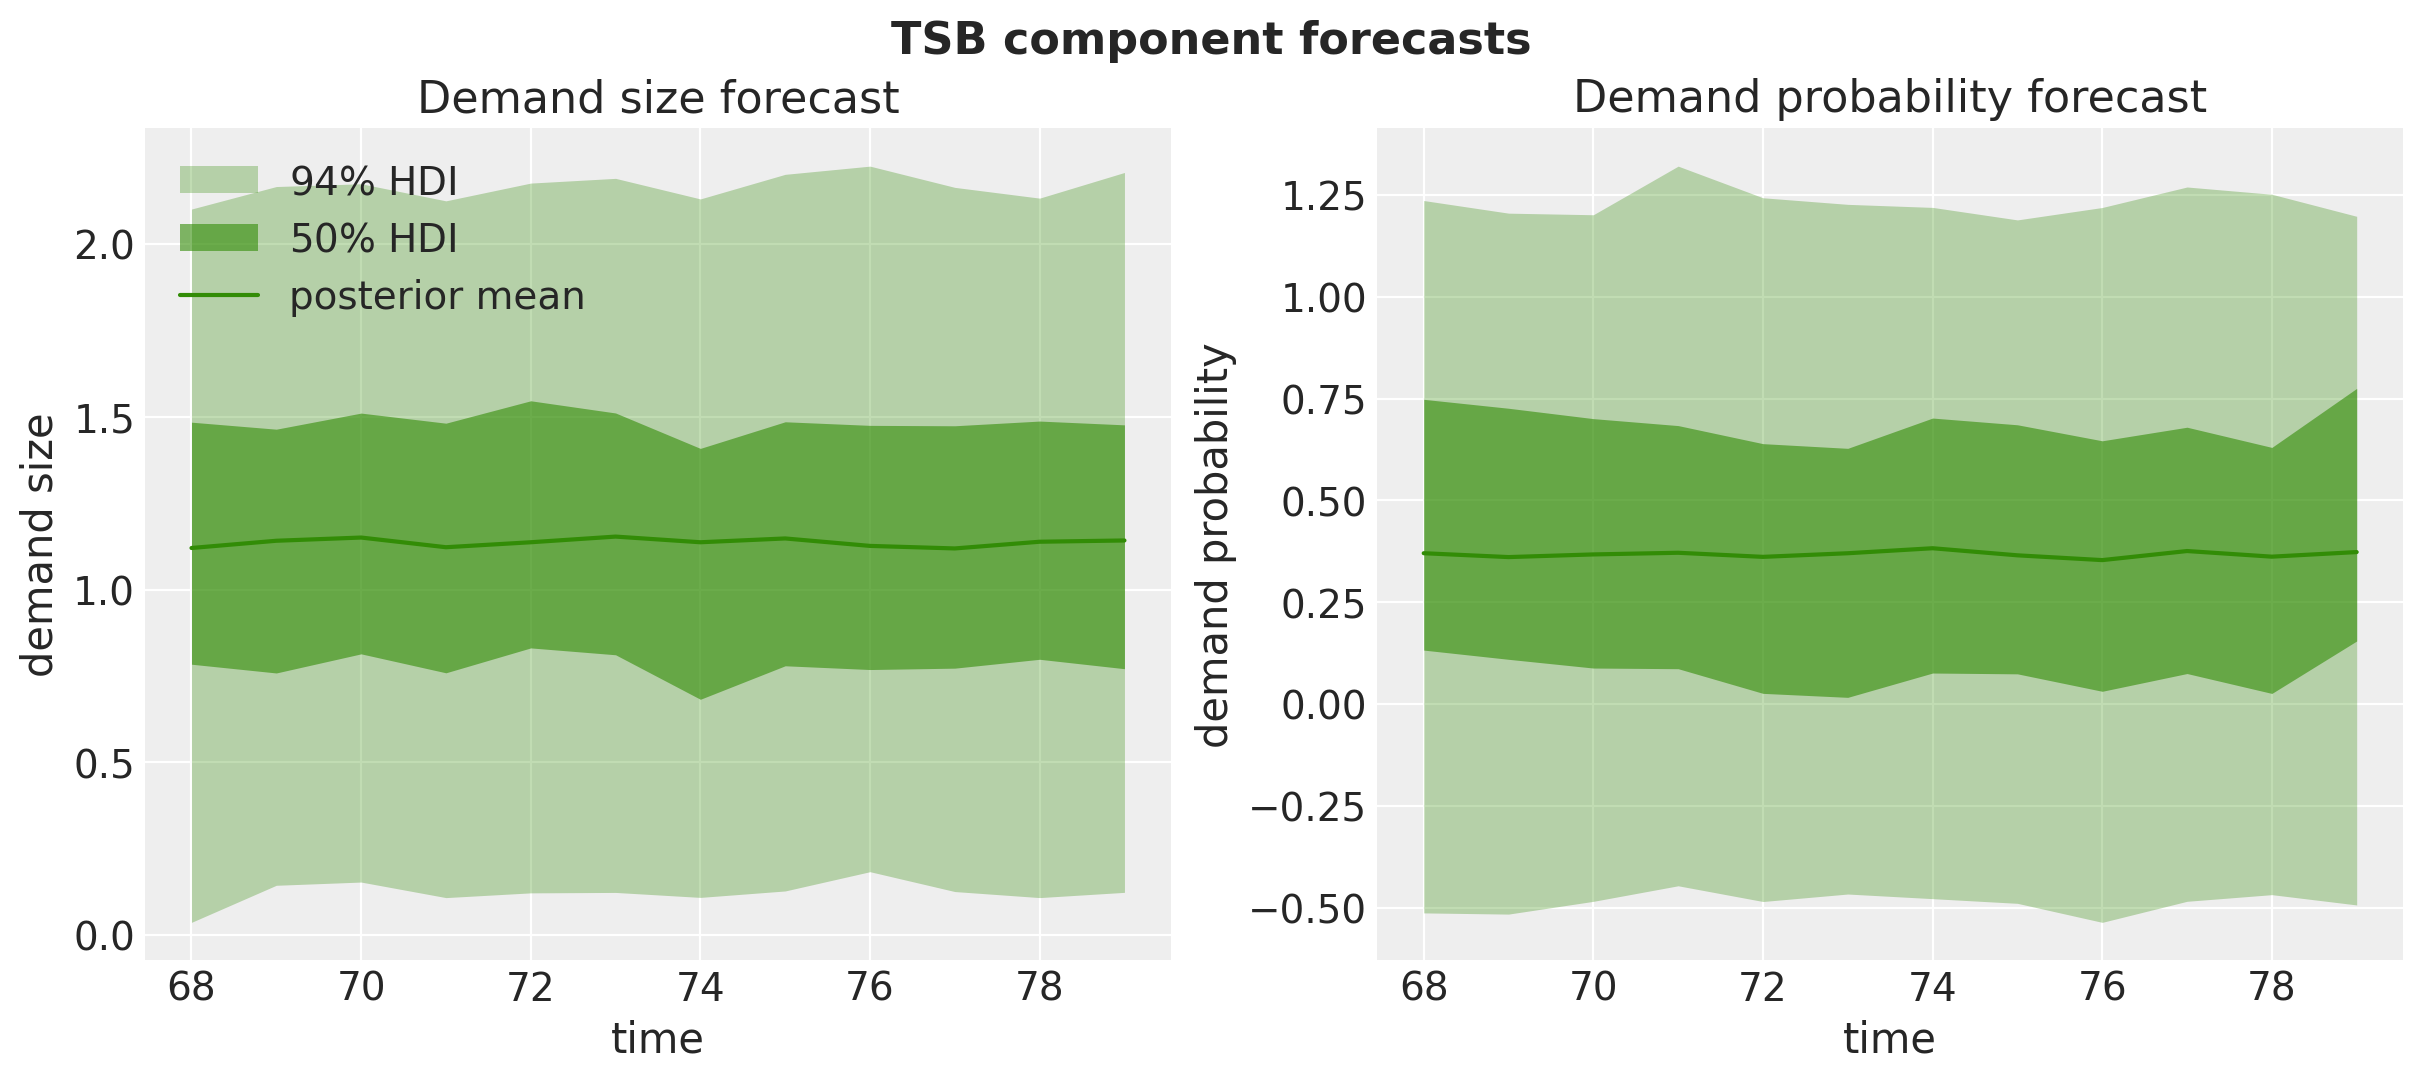

In [13]:
rng_key, rng_subkey = random.split(rng_key)
predictive = Predictive(
    model,
    posterior_samples=dict(fit.samples),
    return_sites=["z_forecast", "p_forecast"],
)
component_draws = predictive(rng_subkey, covariates_full, train_data)
components = np.concatenate(
    [
        np.asarray(component_draws["z_forecast"]),
        np.asarray(component_draws["p_forecast"]),
    ],
    axis=-1,
)

idata_components = predictions_to_datatree(
    components, t_test.astype(float), ["demand size", "demand probability"]
)
pc = az.plot_lm(
    idata_components,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C2"},
        "observed_scatter": False,
        "pe_line": {"color": "C2", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 5), "sharex": True},
)
axes = pc.viz["plot"]["t"]
axes.sel(series="demand size").item().set(
    title="Demand size forecast", xlabel="time", ylabel="demand size"
)
axes.sel(series="demand probability").item().set(
    title="Demand probability forecast", xlabel="time", ylabel="demand probability"
)
bands = pc.viz["ci_band"]["t"]
band_94 = bands.sel(series="demand size", prob=0.94).item()
band_50 = bands.sel(series="demand size", prob=0.5).item()
band_94.set_label(hdi_label(0.94))
band_50.set_label(hdi_label(0.5))
pe_line = pc.viz["pe_line"]["t"].sel(series="demand size").item()
pe_line.set_label("posterior mean")
axes.sel(series="demand size").item().legend(handles=[band_94, band_50, pe_line], loc="upper left")
fig = pc.viz["figure"].item()
fig.suptitle("TSB component forecasts", fontsize=16, fontweight="bold", y=1.05);

## One-step-ahead cross-validation

The fixed-origin forecast uses one training window. The sharper experiment, and the one where TSB and Croston visibly part ways, is a **rolling-origin, one-step-ahead** evaluation: refit the model on an expanding training window and forecast a single step, repeatedly, across the whole test span. [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html) runs this loop with `test_window=1` and `stride=1`, refitting NUTS on each fold through `HMCForecaster`. With `min_train_window=n_train` the folds tile the test span exactly, one fold per held-out period, and `keep_predictions=True` retains each fold's forecast samples. Alongside the CRPS we track the empirical coverage of the central $50\%$ and $94\%$ intervals.

In [14]:
metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
results = backtest(
    rng_subkey,
    data_full,
    data_full,  # the series doubles as the covariates, sliced per fold by backtest
    lambda: model,
    forecaster_fn=HMCForecaster,
    metrics=metrics,
    test_window=1,  # one-step-ahead forecasts
    stride=1,  # one fold per held-out period
    min_train_window=n_train,  # folds tile the test span exactly
    num_samples=2_000,
    eval_train=False,  # in-sample "obs" scoring is not meaningful here (see above)
    keep_predictions=True,
    forecaster_options={"num_warmup": 1_000, "num_samples": 1_000, "num_chains": 4},
)

split_points = [r.t1 for r in results]
test_crps = [r.metrics["crps"] for r in results]
print(f"folds: {len(results)} (split points: {split_points})")

folds: 12 (split points: [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79])


### One-step-ahead forecasts

Because the folds tile the test span, we can concatenate the per-fold forecast samples into a single array of one-step-ahead predictive draws and plot them in one go.

This is the mirror image of the Croston plot. The [Croston example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html) shows its one-step-ahead forecast **barely moving while zeros accumulate**, because Croston's levels only update at demand events. TSB, updating its probability every period, does the opposite: through a run of zeros the one-step-ahead forecast **slides downward**, and it steps back up when a demand lands. Even on this stationary series, where the true occurrence rate is constant and so the swings are modest, the qualitative behavior is unmistakably different: TSB's forecast tracks the recency of demand, which is precisely Croston's structural blind spot.

assembled one-step-ahead draws: (2000, 12, 1)


/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


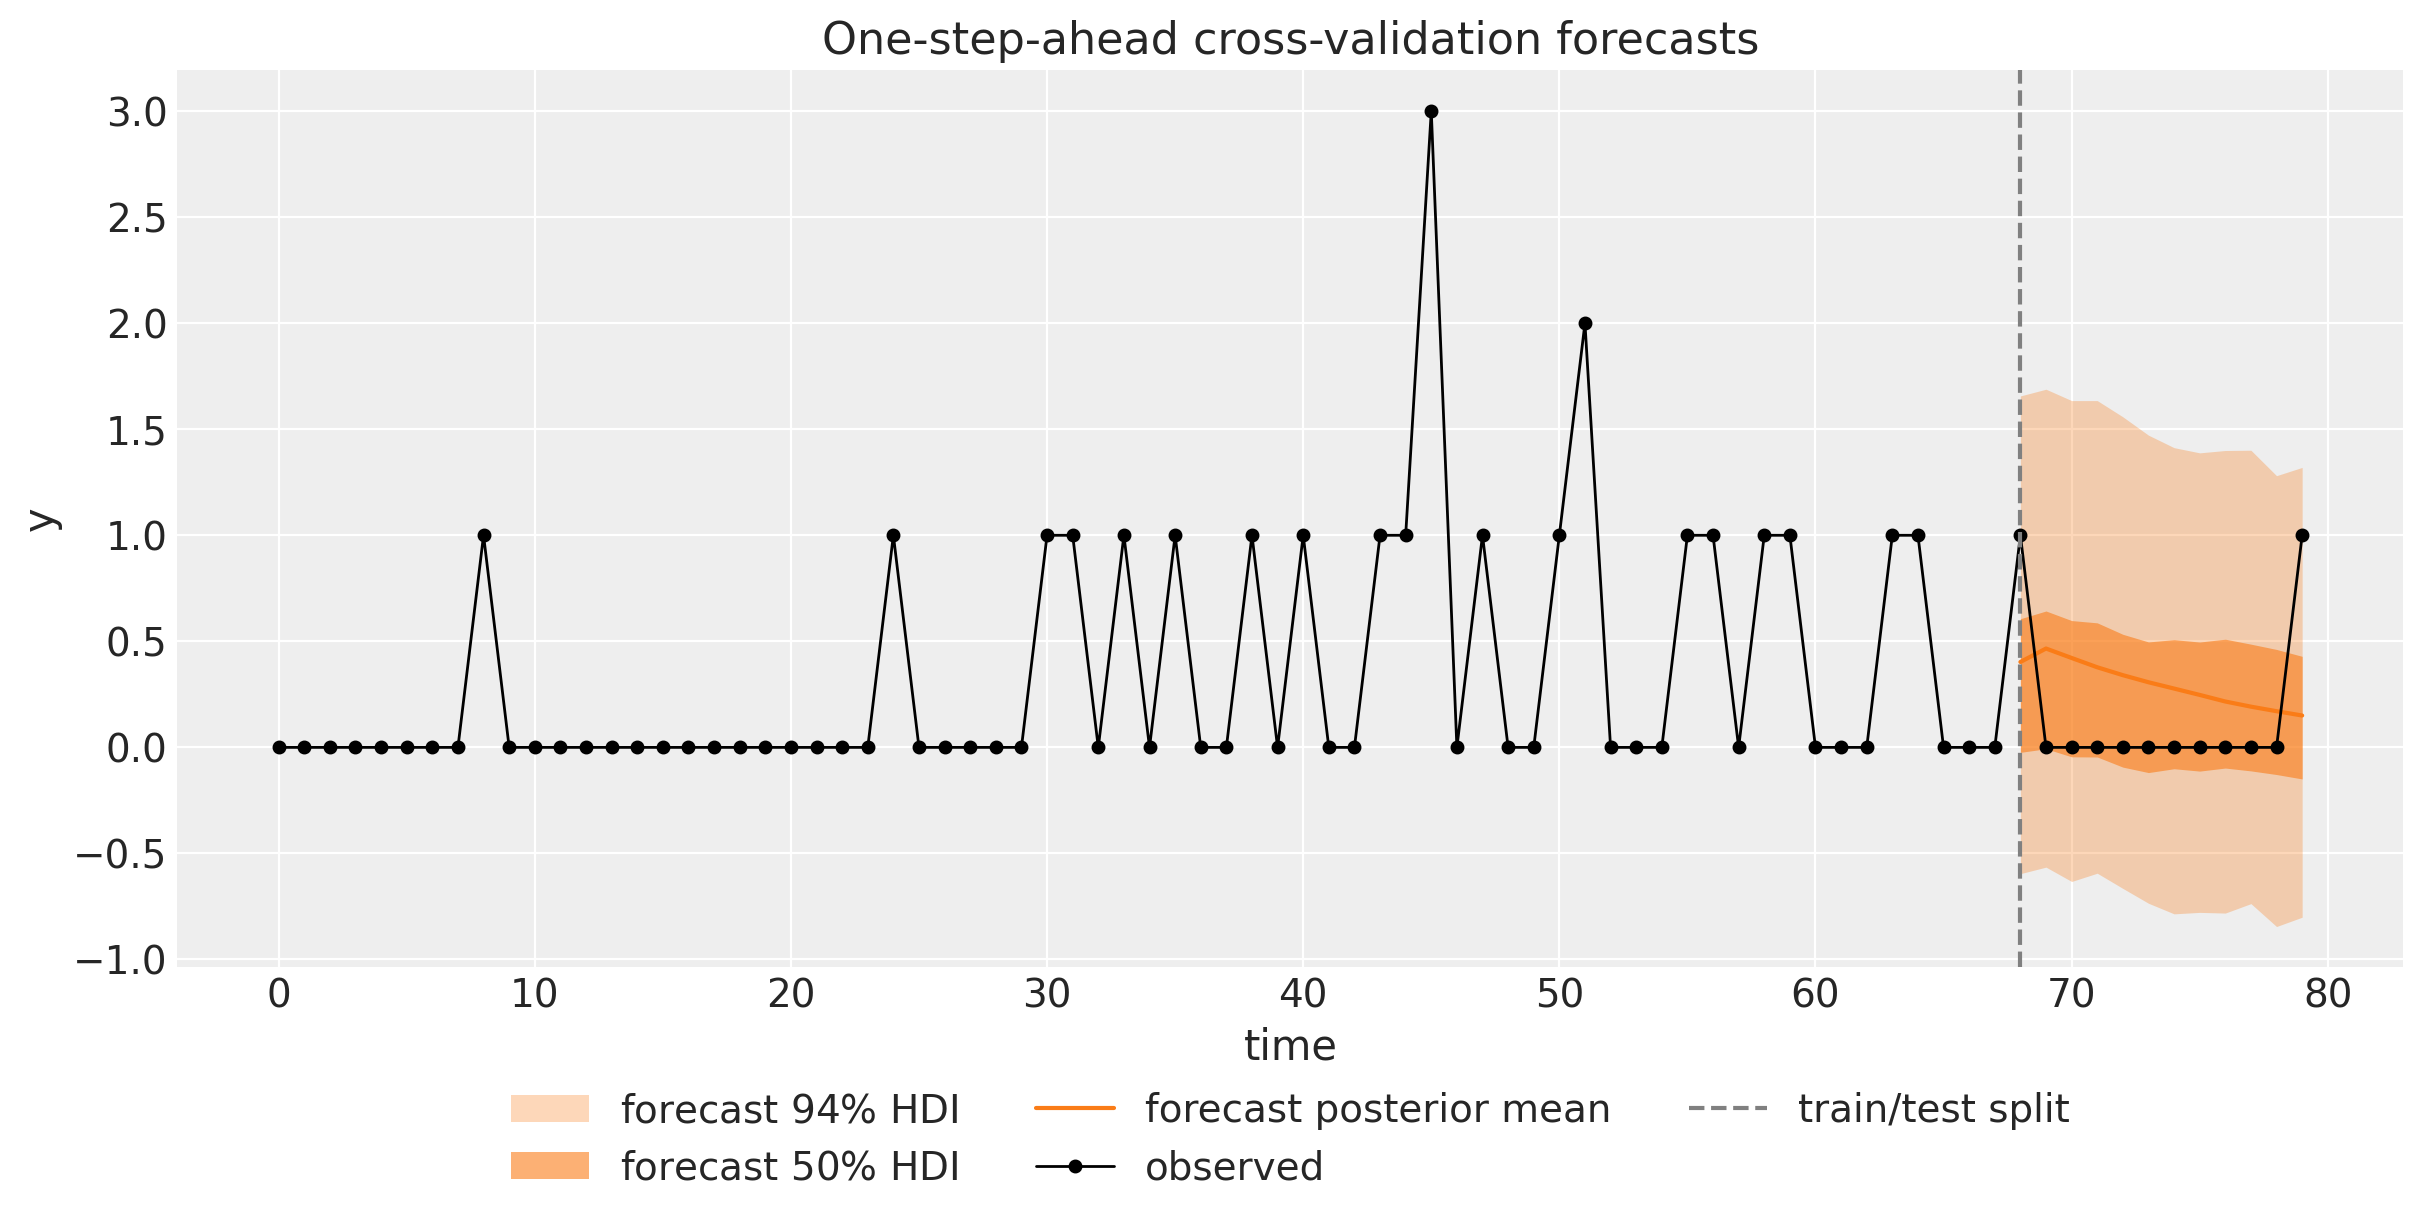

In [15]:
predictions = [r.prediction for r in results if r.prediction is not None]
cv_pred = np.concatenate([np.asarray(pred) for pred in predictions], axis=1)
print(f"assembled one-step-ahead draws: {cv_pred.shape}")

ax, handles = plot_band_forecast(
    cv_pred, t_test.astype(float), "C1", label_prefix="forecast ", observed=test_data
)
(obs_line,) = ax.plot(t, np.asarray(y), "o-", color="black", lw=1, ms=4, label="observed")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="One-step-ahead cross-validation forecasts", xlabel="time", ylabel="y");

### CRPS per fold

The per-fold CRPS makes the same point numerically. Where Croston's per-fold score sits at essentially two flat levels (its forecast never moves), TSB's score **glides**: through the run of held-out zeros the forecast decays steadily toward zero, fitting each accumulating zero a little better, so the CRPS falls smoothly across the drought. It jumps back up only at the two held-out demands (the first fold and the last), where the now-low forecast misses a realized $1$. This is the opposite of Croston's pattern, where the inflated, frozen rate scores the demands *better* than the zeros; TSB's decaying rate instead pays its price on the demands and earns it back across the far more numerous zeros.

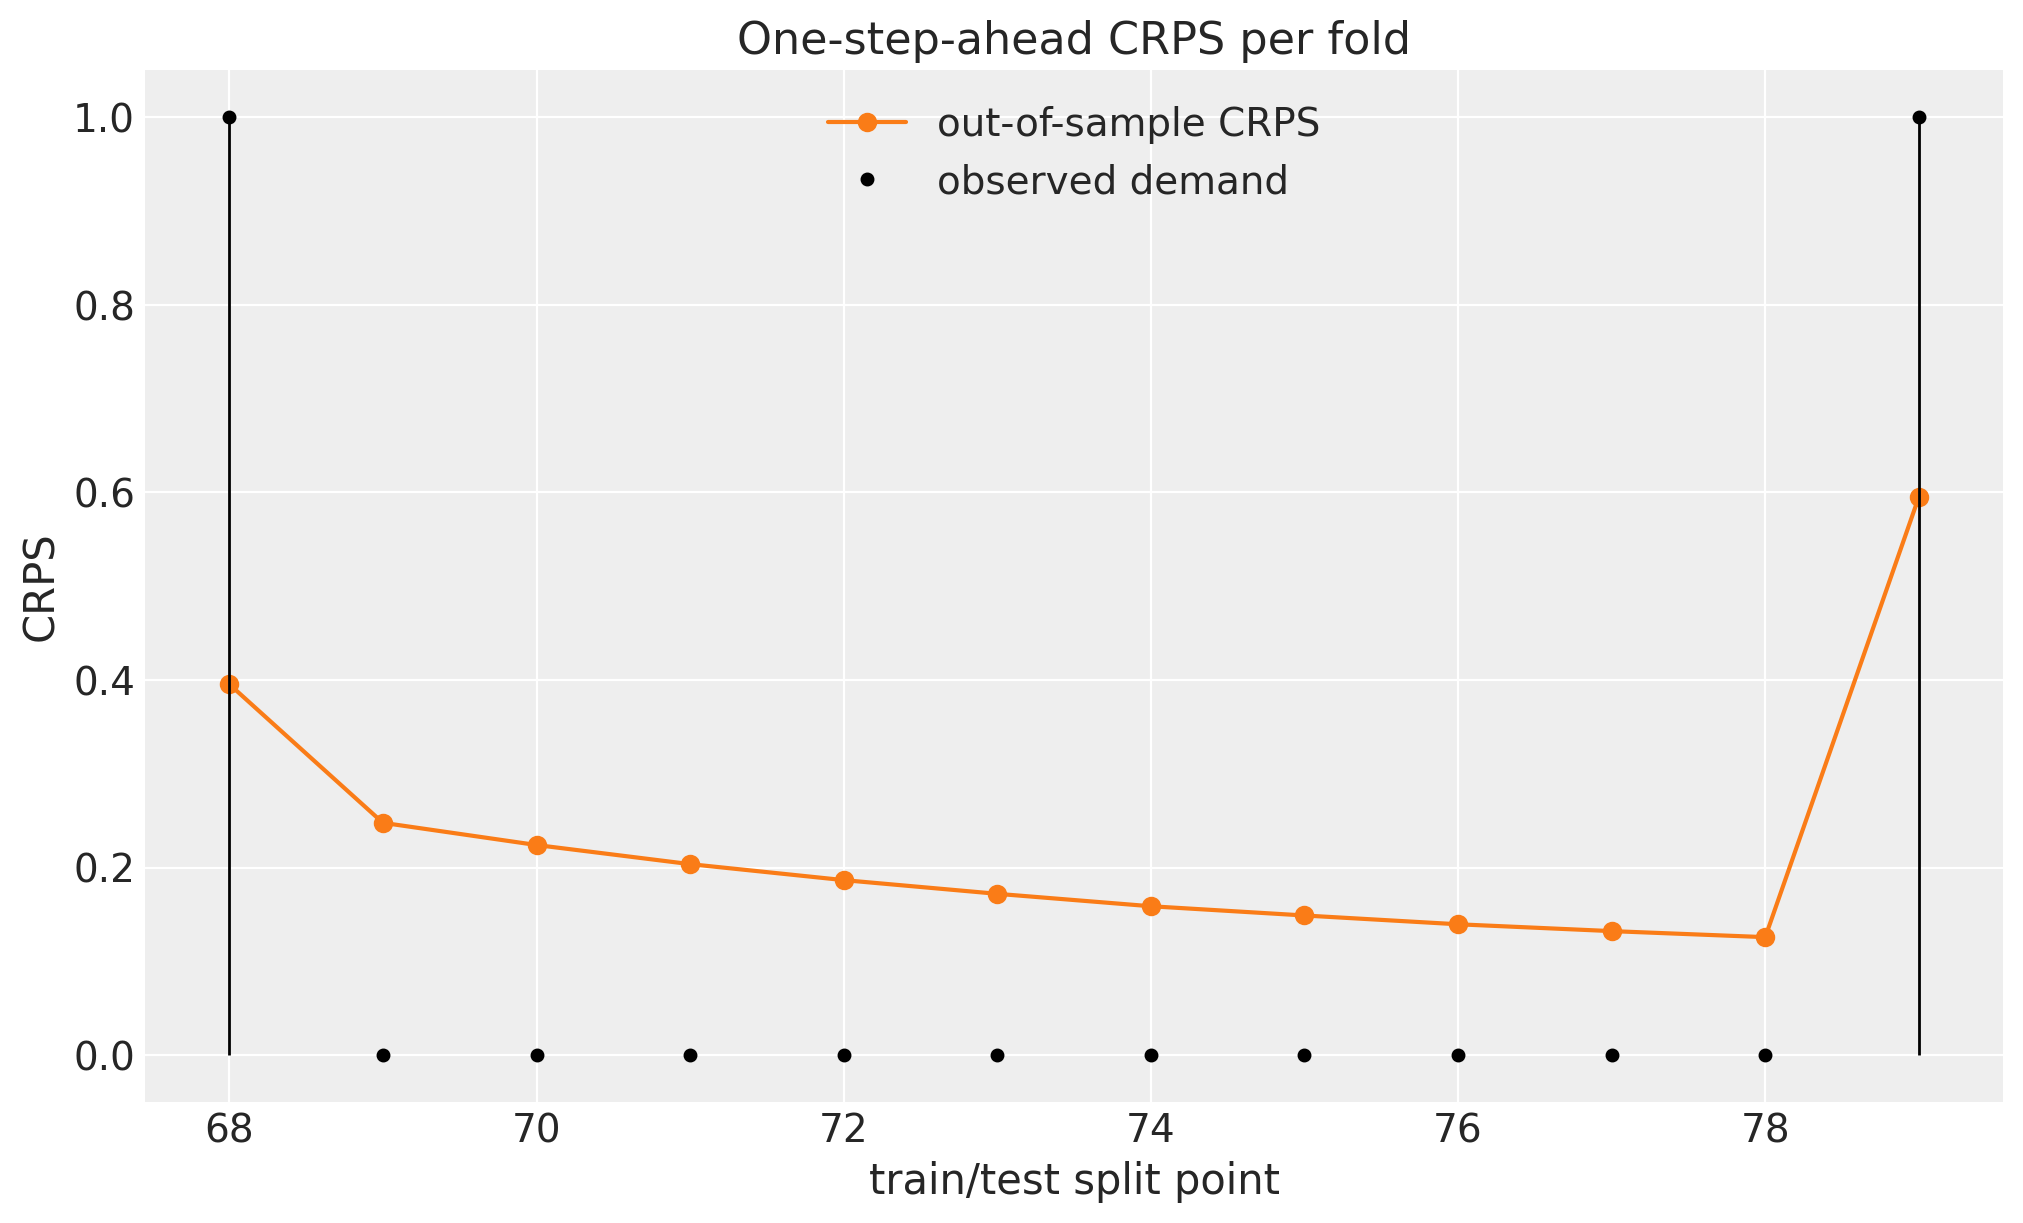

In [16]:
fig, ax = plt.subplots()
ax.plot(split_points, test_crps, "o-", color="C1", label="out-of-sample CRPS")
markerline, stemlines, baseline = ax.stem(t_test, np.asarray(y_test), basefmt=" ")
plt.setp(markerline, color="black", markersize=4, label="observed demand")
plt.setp(stemlines, color="black", linewidth=1)
ax.legend()
ax.set(
    xlabel="train/test split point",
    ylabel="CRPS",
    title="One-step-ahead CRPS per fold",
);

### Calibration

With a single observation per fold, per-fold coverage is a $0/1$ indicator, so we aggregate: the empirical coverage across all folds against the nominal levels, computed from the assembled draws with `eval_coverage`. We also compare the one-step-ahead CRPS with the fixed-origin CRPS from the forecast section.

The same caveat as in the Croston notebook applies: `eval_coverage` measures coverage of the *central quantile interval*, while the plotted bands are HDIs, and for this right-skewed predictive the two genuinely differ, so these numbers check the calibration of central intervals rather than literally of the bands shown above.

In [17]:
cv_crps = eval_crps(cv_pred, test_data)
cov_50 = eval_coverage(cv_pred, test_data, alpha=0.5)
cov_94 = eval_coverage(cv_pred, test_data, alpha=0.94)

print(f"one-step-ahead CRPS over the test span: {cv_crps:.4f}")
print(f"fixed-origin CRPS over the test span:   {crps_test:.4f}")
print(f"empirical 50% coverage: {cov_50:.2f}  (nominal 0.50)")
print(f"empirical 94% coverage: {cov_94:.2f}  (nominal 0.94)")

one-step-ahead CRPS over the test span: 0.2276
fixed-origin CRPS over the test span:   0.2440
empirical 50% coverage: 0.58  (nominal 0.50)
empirical 94% coverage: 1.00  (nominal 0.94)


On this series TSB actually comes out **ahead** of Croston, and for an instructive reason. Its one-step-ahead and fixed-origin CRPS (both around $0.23$ to $0.24$) are lower than the Croston notebook's (both around $0.35$ to $0.37$), and its central $50\%$ interval covers close to nominal ($0.58$ against $0.50$) where Croston's covered almost nothing ($0.08$). Two things drive this. First, TSB smooths a probability directly, so it avoids the upward inversion bias that inflates the Croston rate; its fitted rate sits lower, much closer to the zero-heavy realizations. Second, the forecast's spread reaches down across zero (partly, it must be said, because the Gaussian probability channel spills below zero, which a $\text{Bernoulli}$ channel would achieve more honestly), so the interval actually contains the zeros that dominate the series. The one structural weakness both methods share, a predictive of a *rate* rather than a *count*, is what still keeps the coverage from being exact. And the headline advantage, a forecast that decays when demand truly stops, does not show up in the aggregate score on i.i.d. data at all: it stays latent here, waiting for a series that genuinely goes obsolete to turn it into a decisive difference.

## A final note: TSB versus ARMA

It is worth being explicit about why a classical ARMA model is not the tool here. ARMA (and ARIMA) describe a continuous, autocorrelated series fluctuating around a stable mean with additive noise, and they forecast by extrapolating that autocorrelation. Intermittent demand breaks every one of those assumptions: the series is mostly exact zeros with a spike-at-zero marginal, the per-period mean is a tiny rate rather than a level to revert to, and an ARMA fit would smear a smooth continuous prediction across the zeros while never separating *how much* is demanded from *whether* a demand occurs. TSB (like Croston) instead decomposes the series into a demand size and a demand probability, which is the structurally correct representation for this kind of data. What the notebook does share with the [ARMA example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html) is only the mechanical scaffolding, the series-as-covariates carrier and the expanding-window `backtest` loop, not the modeling assumptions.

## References

- Orduz, J. [*TSB Method for Intermittent Time Series Forecasting in NumPyro*](https://juanitorduz.github.io/tsb_numpyro/). The blog post this notebook ports.
- Orduz, J. [*Croston's Method for Intermittent Time Series Forecasting in NumPyro*](https://juanitorduz.github.io/croston_numpyro/), and the [Croston example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html) in this documentation. The predecessor method this notebook is contrasted against.
- Orduz, J. [*Notes on Exponential Smoothing with NumPyro*](https://juanitorduz.github.io/exponential_smoothing_numpyro/). The predecessor post whose level model both notebooks reuse.
- Teunter, R. H., Syntetos, A. A., & Babai, M. Z. (2011). *Intermittent demand: Linking forecasting to inventory obsolescence*. European Journal of Operational Research, 214(3), 606-615. The paper that introduces the TSB method.
- Croston, J. D. (1972). *Forecasting and stock control for intermittent demands*. Operational Research Quarterly, 23(3), 289-303.
- Morgan, P. [*Adaptations of Croston's Method*](https://www.pmorgan.com.au/tutorials/adaptations-of-crostons-method/). A tutorial covering TSB alongside the other Croston variants.
- statsforecast documentation: [`TSB`](https://nixtlaverse.nixtla.io/statsforecast/docs/models/tsb.html), the classical baseline the blog post compares against.
- The [ARMA example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html) in this documentation, which introduces the series-as-covariates pattern and the expanding-window `backtest` workflow.